In [2]:
! pip install -q xarray zarr gcsfs cftime nc-time-axis

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## CMIP6 Climate Data — Exploratory Analysis

The CMIP6 catalog is a CSV where each row points to one climate model simulation stored on Google Cloud.
We use it to find and stream data without downloading any large files.

**Key columns**
| Column | Meaning |
|---|---|
| `source_id` | Climate model name (e.g. CanESM5) |
| `experiment_id` | Scenario: `historical` = 1850–2014, `ssp585` = high-emission future |
| `variable_id` | What is measured: `tas` = air temp, `pr` = rain, `siconc` = sea ice |
| `zstore` | Google Cloud path to the actual data |

In [4]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
print(f'Catalog size: {len(df):,} datasets')
df.head(3)

Catalog size: 523,774 datasets


,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


---
### Exploratory (Not Counted) — What Climate Scenarios Exist?
Each bar shows how many model runs are available for a given scenario.

**What SSP labels mean (simple):**
- **SSP1-2.6**: strong mitigation (rapid emissions cuts) -> lower warming pathway.
- **SSP2-4.5**: intermediate pathway -> moderate warming.
- **SSP5-8.5**: very high emissions -> highest warming risk.

**Why these are important and mentioned:**
They are standardized futures used across many models, so we can compare outcomes consistently.
Using multiple SSPs helps answer: *how much climate risk changes if society emits less vs more?*

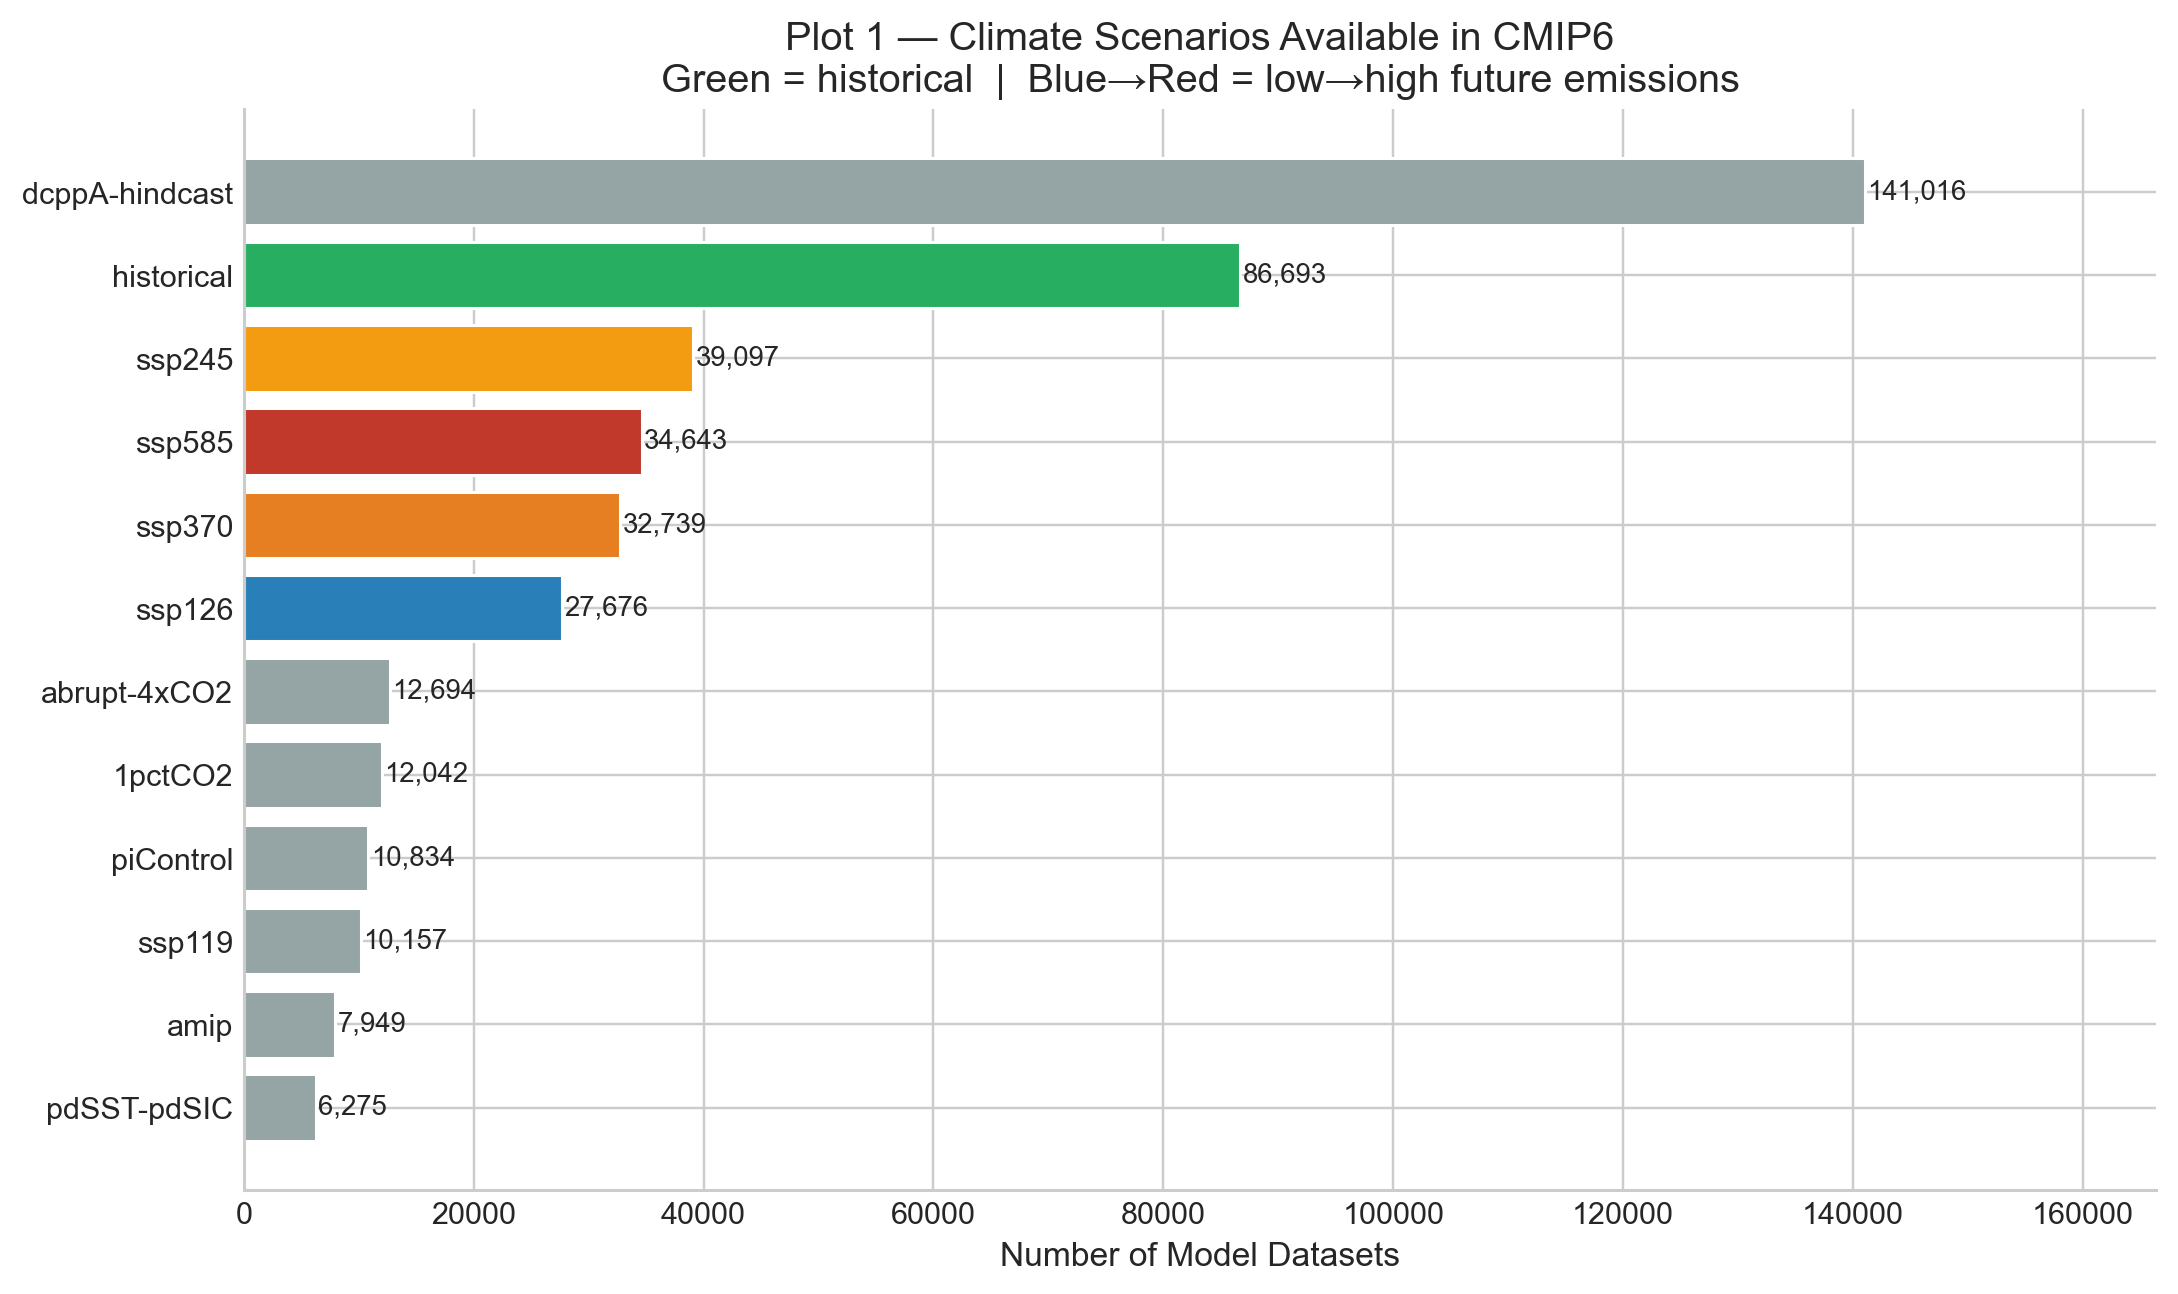

In [5]:
exp_counts = df['experiment_id'].value_counts().head(12)

# Color-code by emission level
def scenario_color(name):
    if 'ssp585' in name: return '#c0392b'
    if 'ssp370' in name: return '#e67e22'
    if 'ssp245' in name: return '#f39c12'
    if 'ssp126' in name: return '#2980b9'
    if 'hist'   in name: return '#27ae60'
    return '#95a5a6'

colors = [scenario_color(e) for e in exp_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(exp_counts.index, exp_counts.values, color=colors, edgecolor='white')
ax.invert_yaxis()

for bar, n in zip(bars, exp_counts.values):
    ax.text(n + 200, bar.get_y() + bar.get_height() / 2,
            f'{n:,}', va='center', fontsize=9)

ax.set_xlabel('Number of Model Datasets')
ax.set_title('Plot 1 — Climate Scenarios Available in CMIP6\n'
             'Green = historical  |  Blue→Red = low→high future emissions')
ax.set_xlim(0, exp_counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Exploratory (Not Counted) — What Climate Variables Are Available?
Each bar shows how many datasets exist for a given measured quantity.
`tas` (air temperature) is the most common, with `pr` (precipitation) and `siconc` (sea ice) also well-covered.

**Paris Agreement context (why this matters):**
The Paris Agreement is a 2015 global treaty where countries agreed to keep warming
well below 2.0°C and pursue efforts to limit warming to 1.5°C above pre-industrial levels.
These targets are referenced in later temperature plots.

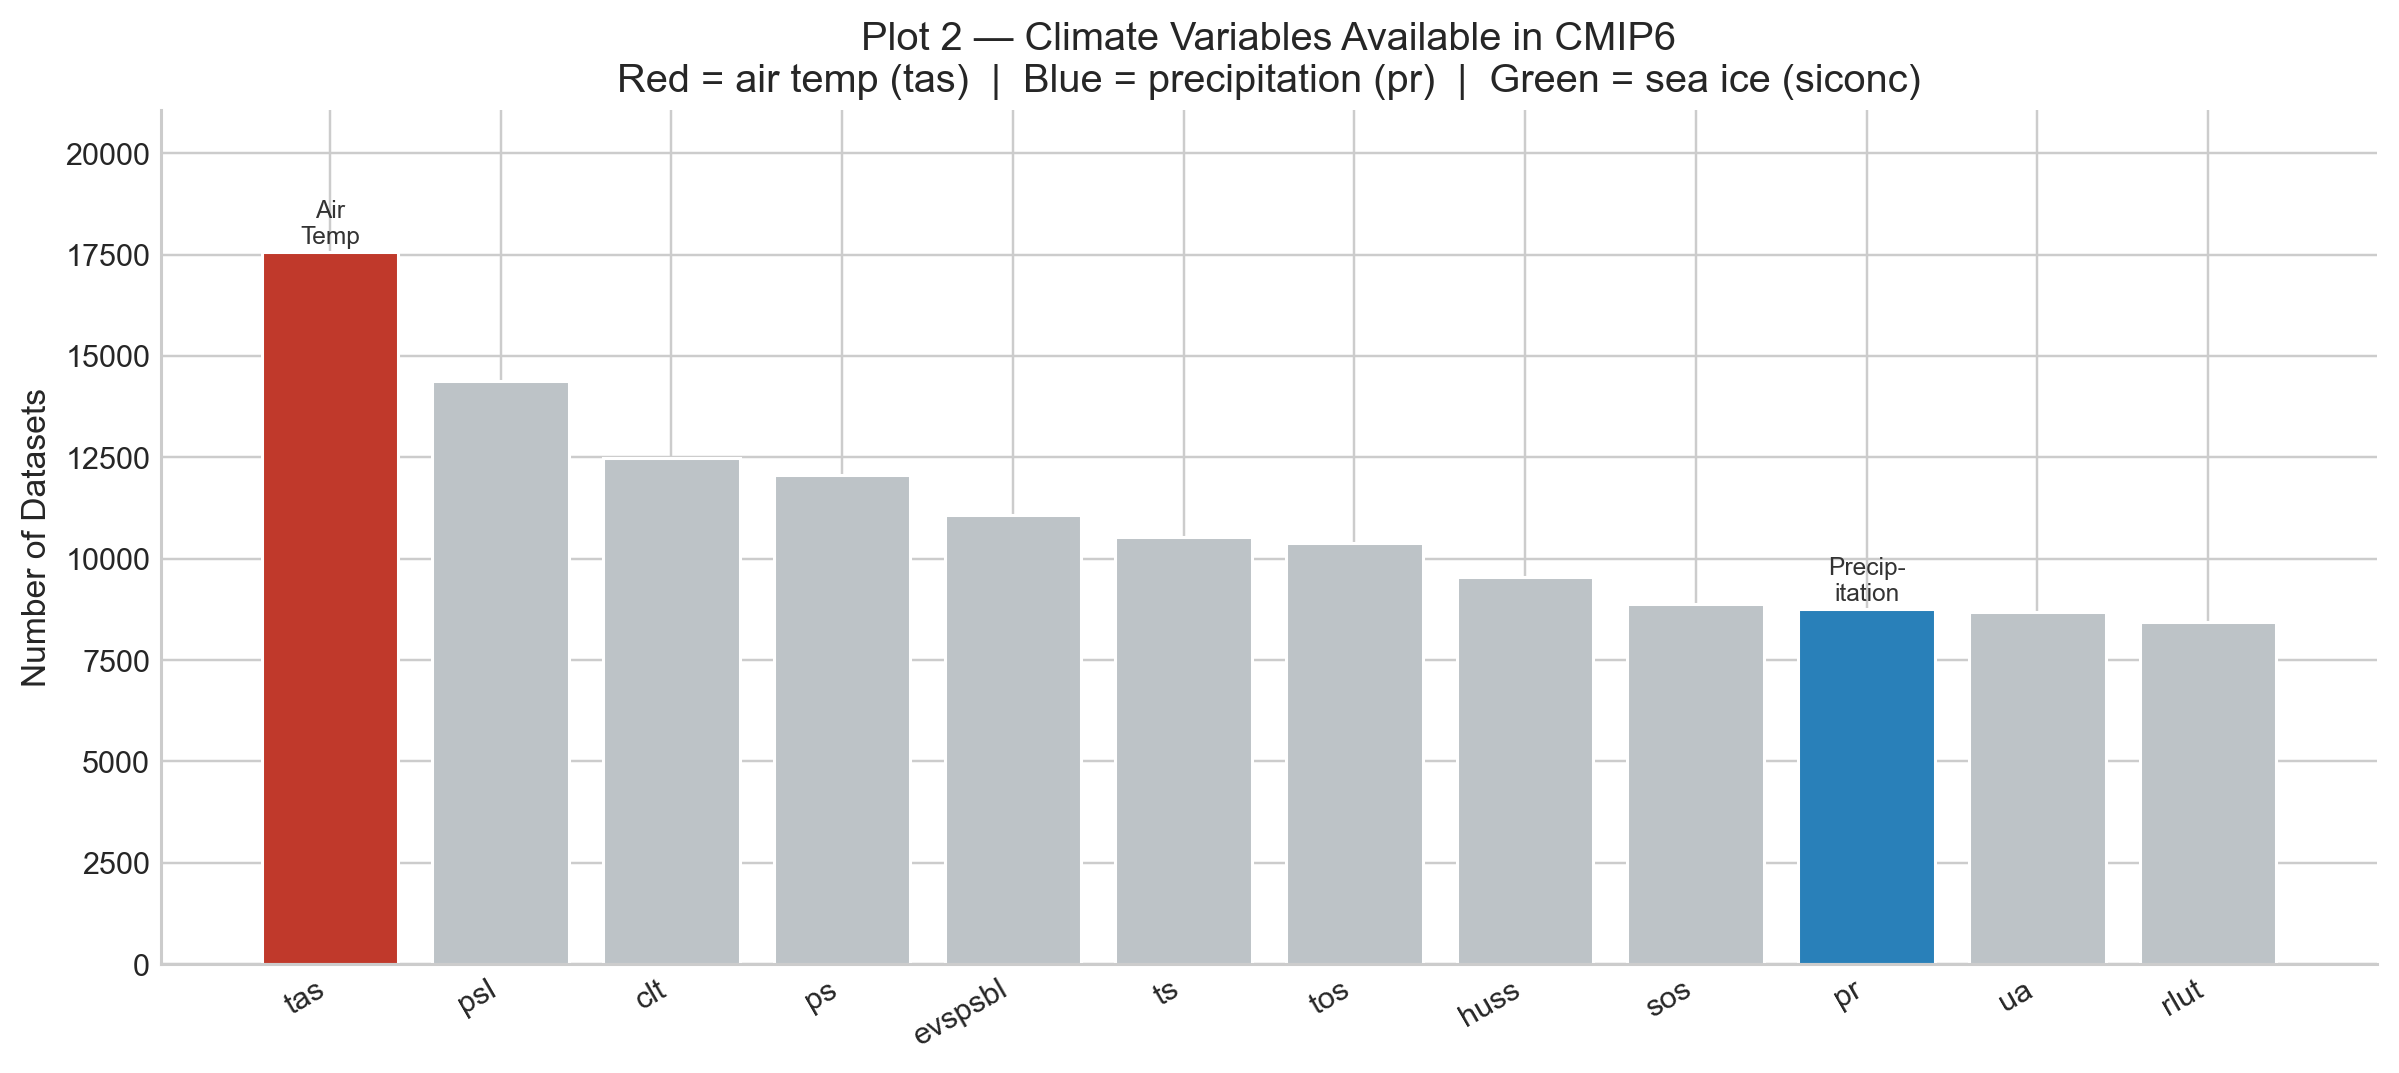

In [6]:
var_counts = df['variable_id'].value_counts().head(12)

# Highlight the three variables we'll actually load
highlight = {'tas': '#c0392b', 'pr': '#2980b9', 'siconc': '#16a085'}
colors = [highlight.get(v, '#bdc3c7') for v in var_counts.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(var_counts.index, var_counts.values, color=colors, edgecolor='white')

# Label the highlighted variables
labels = {'tas': 'Air\nTemp', 'pr': 'Precip-\nitation', 'siconc': 'Sea\nIce'}
for i, v in enumerate(var_counts.index):
    if v in labels:
        ax.text(i, var_counts.values[i] + 200, labels[v],
                ha='center', fontsize=8, color='#333')

ax.set_ylabel('Number of Datasets')
ax.set_title('Plot 2 — Climate Variables Available in CMIP6\n'
             'Red = air temp (tas)  |  Blue = precipitation (pr)  |  Green = sea ice (siconc)')
ax.set_ylim(0, var_counts.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
### Impact Plot 1 — Global Temperature Is Rising
We load the CanESM5 model's near-surface air temperature (`tas`) for two periods:
- **historical** (1850–2014): model simulations using observed past forcings
- **SSP5-8.5** (2015–2100): high-emission future projection

**Scenario/model guide:**
- A **climate model** (here: CanESM5) is the simulator.
- An **experiment/scenario** (historical, SSP1-2.6, SSP2-4.5, SSP5-8.5) is the forcing pathway fed to the model.

**Why plotting the future is important:**
Future plots are decision tools: they estimate likely impacts before they occur,
so we can compare pathways, quantify avoided warming, and plan mitigation/adaptation earlier.

The y-axis shows the **anomaly** — how much warmer than the 1850–1900 average.

> ⏱ *This cell streams data from Google Cloud — allow ~1–2 minutes.*

Loading temperature data...
  loaded tas/historical: 1850-01 to 2014-12


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded tas/ssp585: 2015-01 to 2300-12


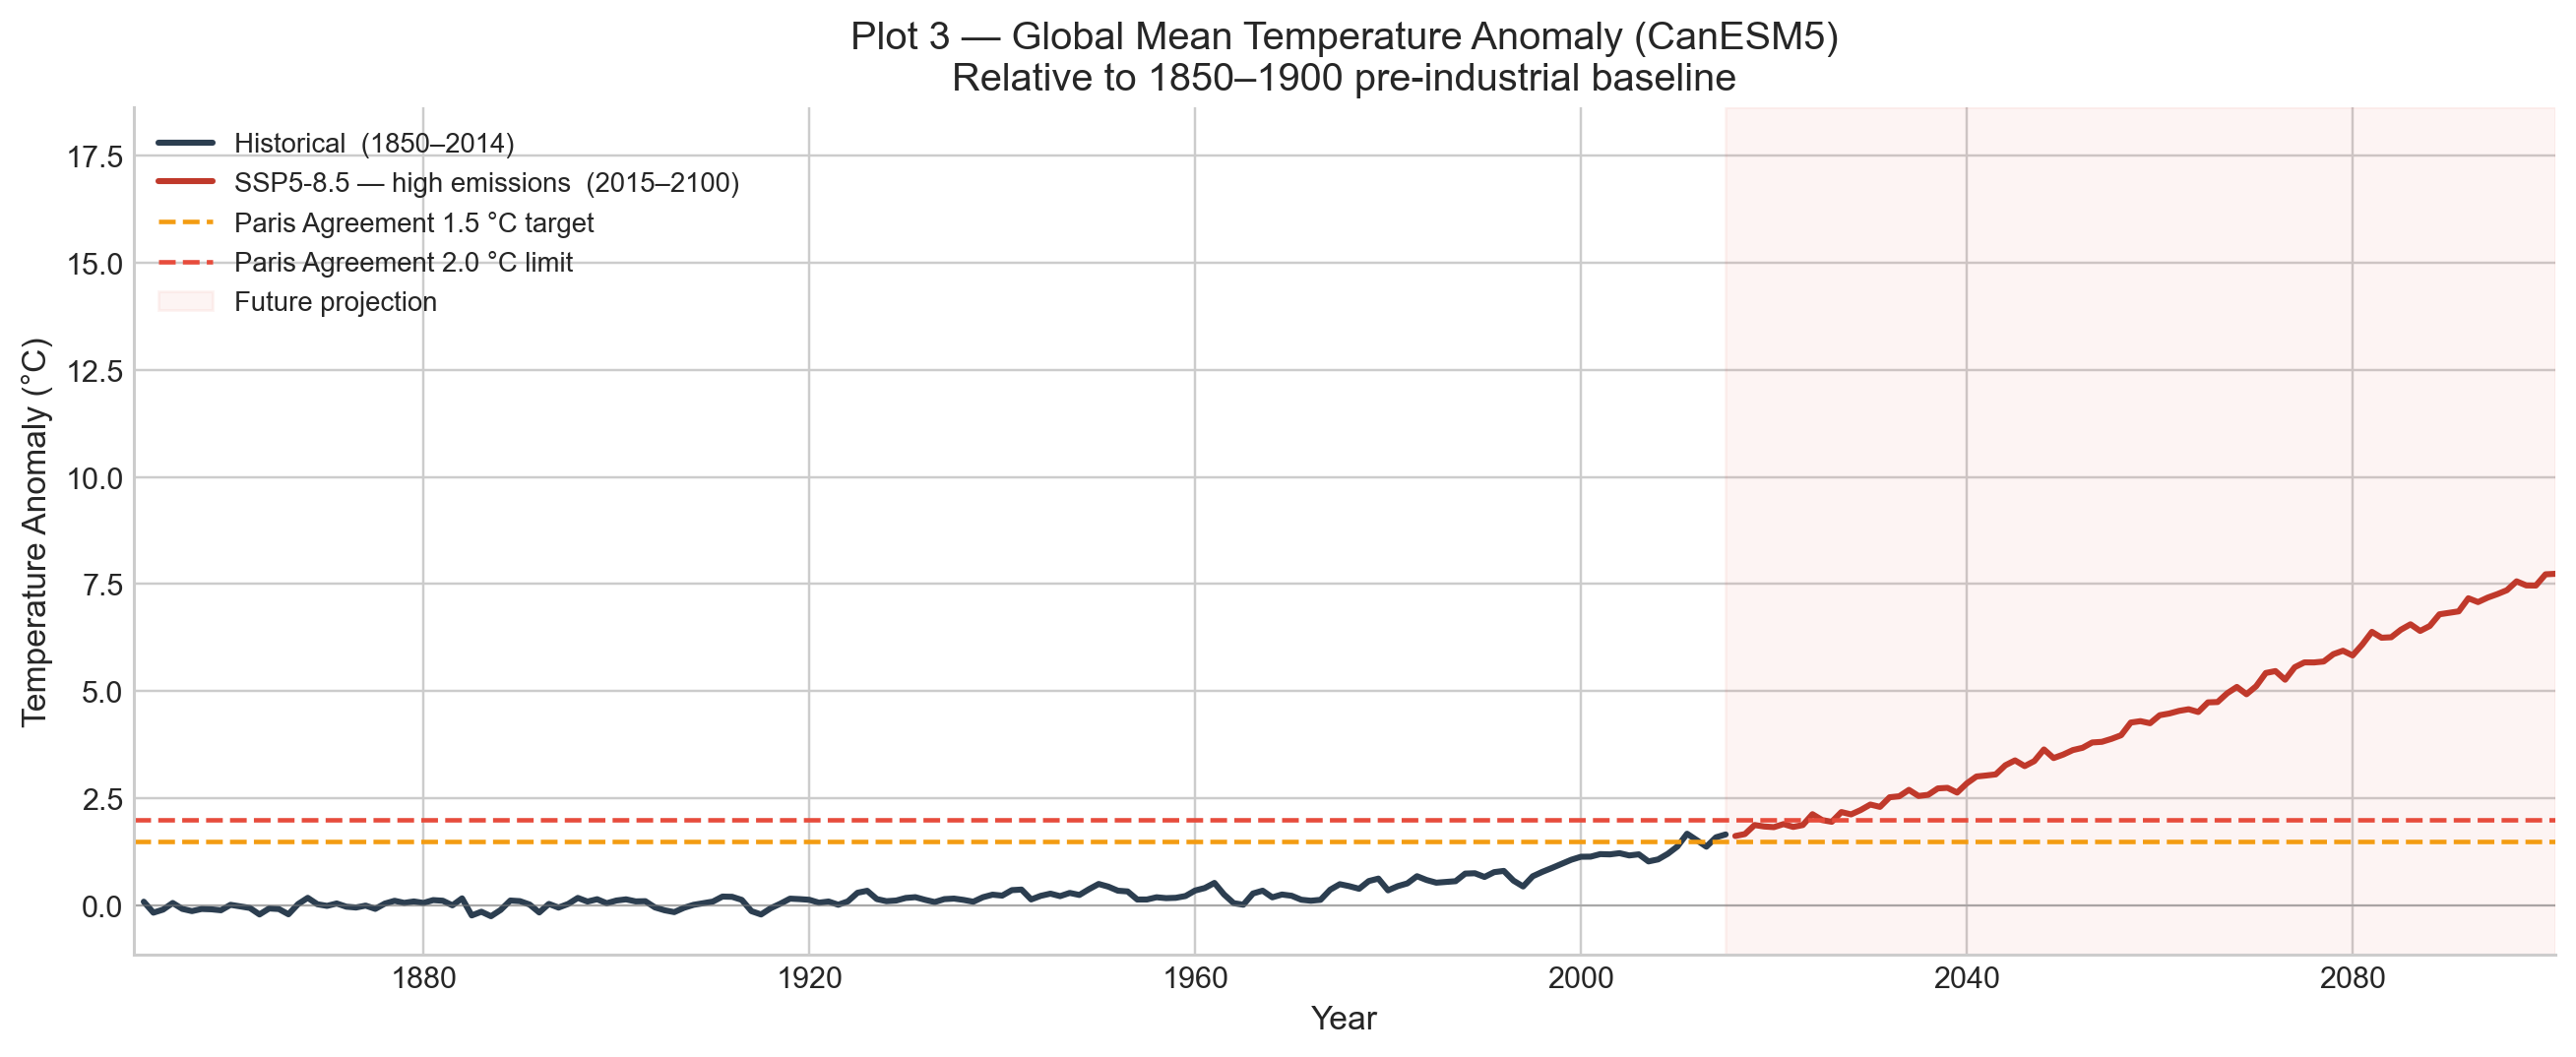

In [17]:
# --- Step 1: connect to Google Cloud (no login needed) ----------------------
gcs = gcsfs.GCSFileSystem(token='anon')

def open_cmip6(variable, experiment, table='Amon'):
    """Filter catalog, open the Zarr store, return an xarray Dataset."""
    row = df[
        (df.variable_id   == variable)   &
        (df.experiment_id == experiment) &
        (df.source_id     == 'CanESM5') &
        (df.table_id      == table)      &
        (df.member_id     == 'r1i1p1f1') &
        (df.grid_label    == 'gn')
    ]
    if len(row) == 0:   # try without the table filter as fallback
        row = df[(df.variable_id == variable) & (df.experiment_id == experiment) &
                 (df.source_id == 'CanESM5') & (df.member_id == 'r1i1p1f1')]
    ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)
    print(f'  loaded {variable}/{experiment}: '
          f'{str(ds.time.values[0])[:7]} to {str(ds.time.values[-1])[:7]}')
    return ds

def global_mean_C(ds, var='tas'):
    """Area-weighted global mean, Kelvin -> Celsius, annual average."""
    w = np.cos(np.deg2rad(ds.lat));  w.name = 'weights'
    return (ds[var].weighted(w).mean(('lat', 'lon')) - 273.15).resample(time='YE').mean()

def to_dates(da):
    """Convert xarray time coordinate to pandas DatetimeIndex."""
    return pd.to_datetime([str(t)[:10] for t in da.time.values])

# --- Step 2: load temperature data ------------------------------------------
print('Loading temperature data...')
ds_hist = open_cmip6('tas', 'historical')
ds_ssp  = open_cmip6('tas', 'ssp585')

# --- Step 3: compute global mean and anomaly --------------------------------
gm_hist = global_mean_C(ds_hist)
gm_ssp  = global_mean_C(ds_ssp)
baseline = float(gm_hist.sel(time=slice('1850', '1900')).mean())  # pre-industrial average

# --- Step 4: plot -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(to_dates(gm_hist), gm_hist.values - baseline,
        color='#2c3e50', lw=2,   label='Historical  (1850–2014)')
ax.plot(to_dates(gm_ssp),  gm_ssp.values  - baseline,
        color='#c0392b', lw=2,   label='SSP5-8.5 — high emissions  (2015–2100)')

ax.axhline(1.5, color='#f39c12', linestyle='--', lw=1.5, label='Paris Agreement 1.5 °C target')
ax.axhline(2.0, color='#e74c3c', linestyle='--', lw=1.5, label='Paris Agreement 2.0 °C limit')
ax.axhline(0,   color='gray',    lw=0.6, alpha=0.5)

ax.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2100-12-31'),
           alpha=0.06, color='#e74c3c', label='Future projection')

ax.set_xlim(pd.Timestamp('1850-01-01'), pd.Timestamp('2100-12-31'))
ax.set_title('Plot 3 — Global Mean Temperature Anomaly (CanESM5)\n'
             'Relative to 1850–1900 pre-industrial baseline')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 1B — SSP Comparison for Global Temperature (Line Plot)
This line plot compares global mean temperature anomaly for three SSP pathways using `tas`:
- **SSP1-2.6** (strong mitigation)
- **SSP2-4.5** (intermediate)
- **SSP5-8.5** (very high emissions)

Why this matters: it shows how emissions choices change warming outcomes by 2100.

Loading additional SSP temperature runs...


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded tas/ssp126: 2015-01 to 2300-12
  loaded tas/ssp245: 2015-01 to 2100-12


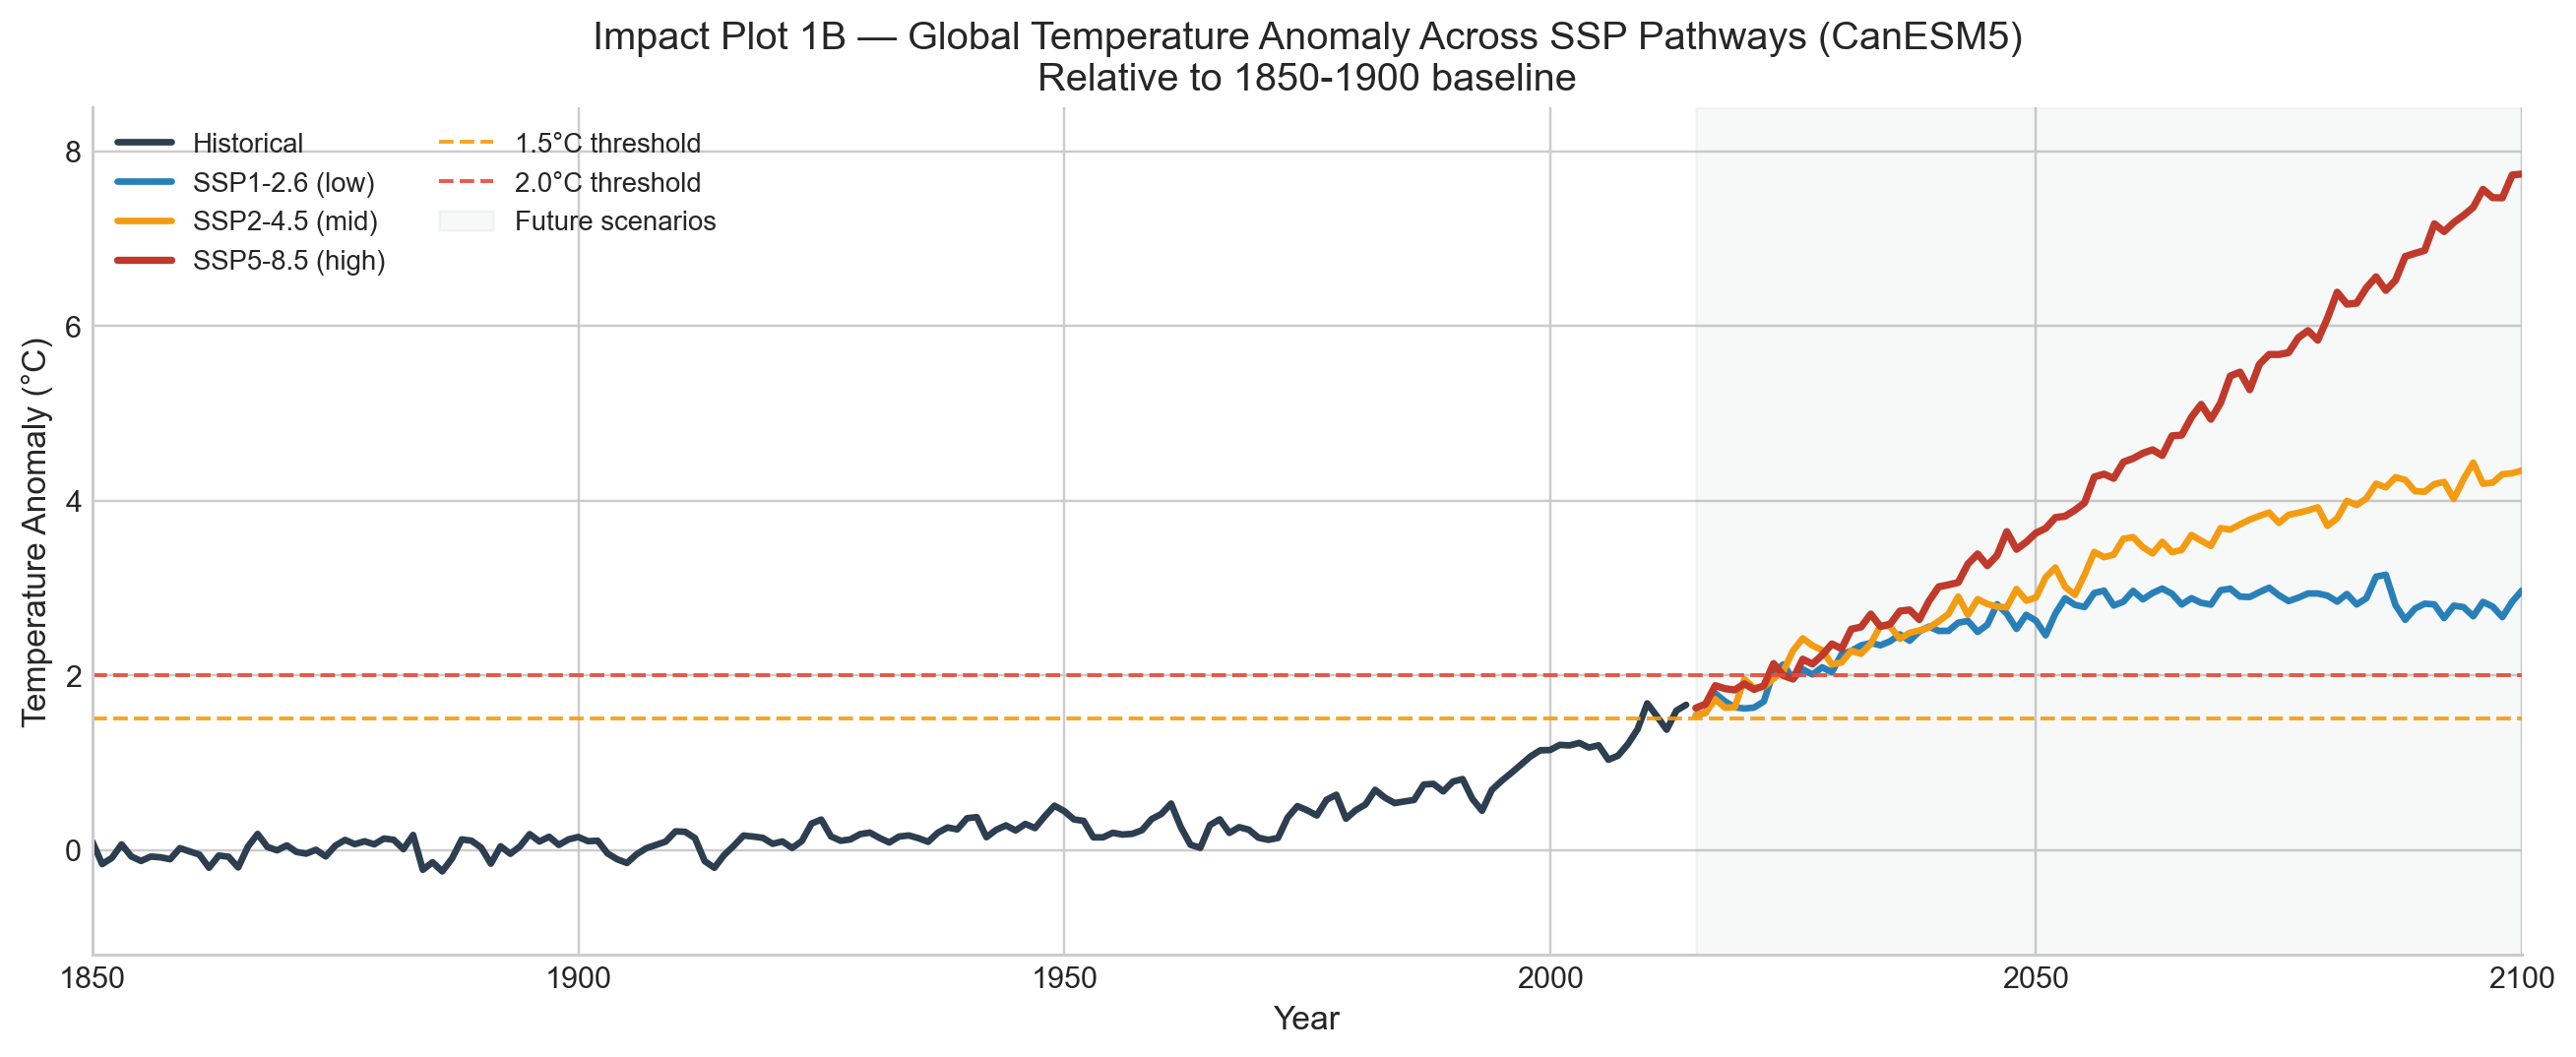

In [8]:
# Reuse historical baseline if available; otherwise compute it
try:
    gm_hist
except NameError:
    ds_hist = open_cmip6('tas', 'historical')
    gm_hist = global_mean_C(ds_hist)

baseline_ssp = float(gm_hist.sel(time=slice('1850', '1900')).mean())

# Load additional SSP runs only if not already in memory
print('Loading additional SSP temperature runs...')
try:
    ds_ssp126
except NameError:
    ds_ssp126 = open_cmip6('tas', 'ssp126')
try:
    ds_ssp245
except NameError:
    ds_ssp245 = open_cmip6('tas', 'ssp245')

# Restrict all future scenarios to 2015-2100 for fair comparison and faster execution
gm_ssp126 = global_mean_C(ds_ssp126.sel(time=slice('2015', '2100')))
gm_ssp245 = global_mean_C(ds_ssp245.sel(time=slice('2015', '2100')))
gm_ssp585 = global_mean_C(ds_ssp.sel(time=slice('2015', '2100')))

def to_years(da):
    return np.array([int(str(t)[:4]) for t in da.time.values])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(to_years(gm_hist),   gm_hist.values   - baseline_ssp, color='#2c3e50', lw=2.2, label='Historical')
ax.plot(to_years(gm_ssp126), gm_ssp126.values - baseline_ssp, color='#2980b9', lw=2.2, label='SSP1-2.6 (low)')
ax.plot(to_years(gm_ssp245), gm_ssp245.values - baseline_ssp, color='#f39c12', lw=2.2, label='SSP2-4.5 (mid)')
ax.plot(to_years(gm_ssp585), gm_ssp585.values - baseline_ssp, color='#c0392b', lw=2.4, label='SSP5-8.5 (high)')

ax.axhline(1.5, color='#f39c12', linestyle='--', lw=1.3, alpha=0.9, label='1.5°C threshold')
ax.axhline(2.0, color='#e74c3c', linestyle='--', lw=1.3, alpha=0.9, label='2.0°C threshold')
ax.axvspan(2015, 2100, alpha=0.06, color='#7f8c8d', label='Future scenarios')

ax.set_xlim(1850, 2100)
ax.set_ylim(-1.2, 8.5)
ax.set_title('Impact Plot 1B — Global Temperature Anomaly Across SSP Pathways (CanESM5)\n'
             'Relative to 1850-1900 baseline')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 2 — Where Will It Be Hottest?
Using the same temperature data already loaded, we compare the 20-year average
at the *end of the century* (2080–2100, SSP5-8.5) against the *pre-industrial baseline*
(1850–1900, historical). The map shows how much warmer each region will be.

Key pattern: the **Arctic warms 3–4× faster** than the tropics — this is called **polar amplification**.

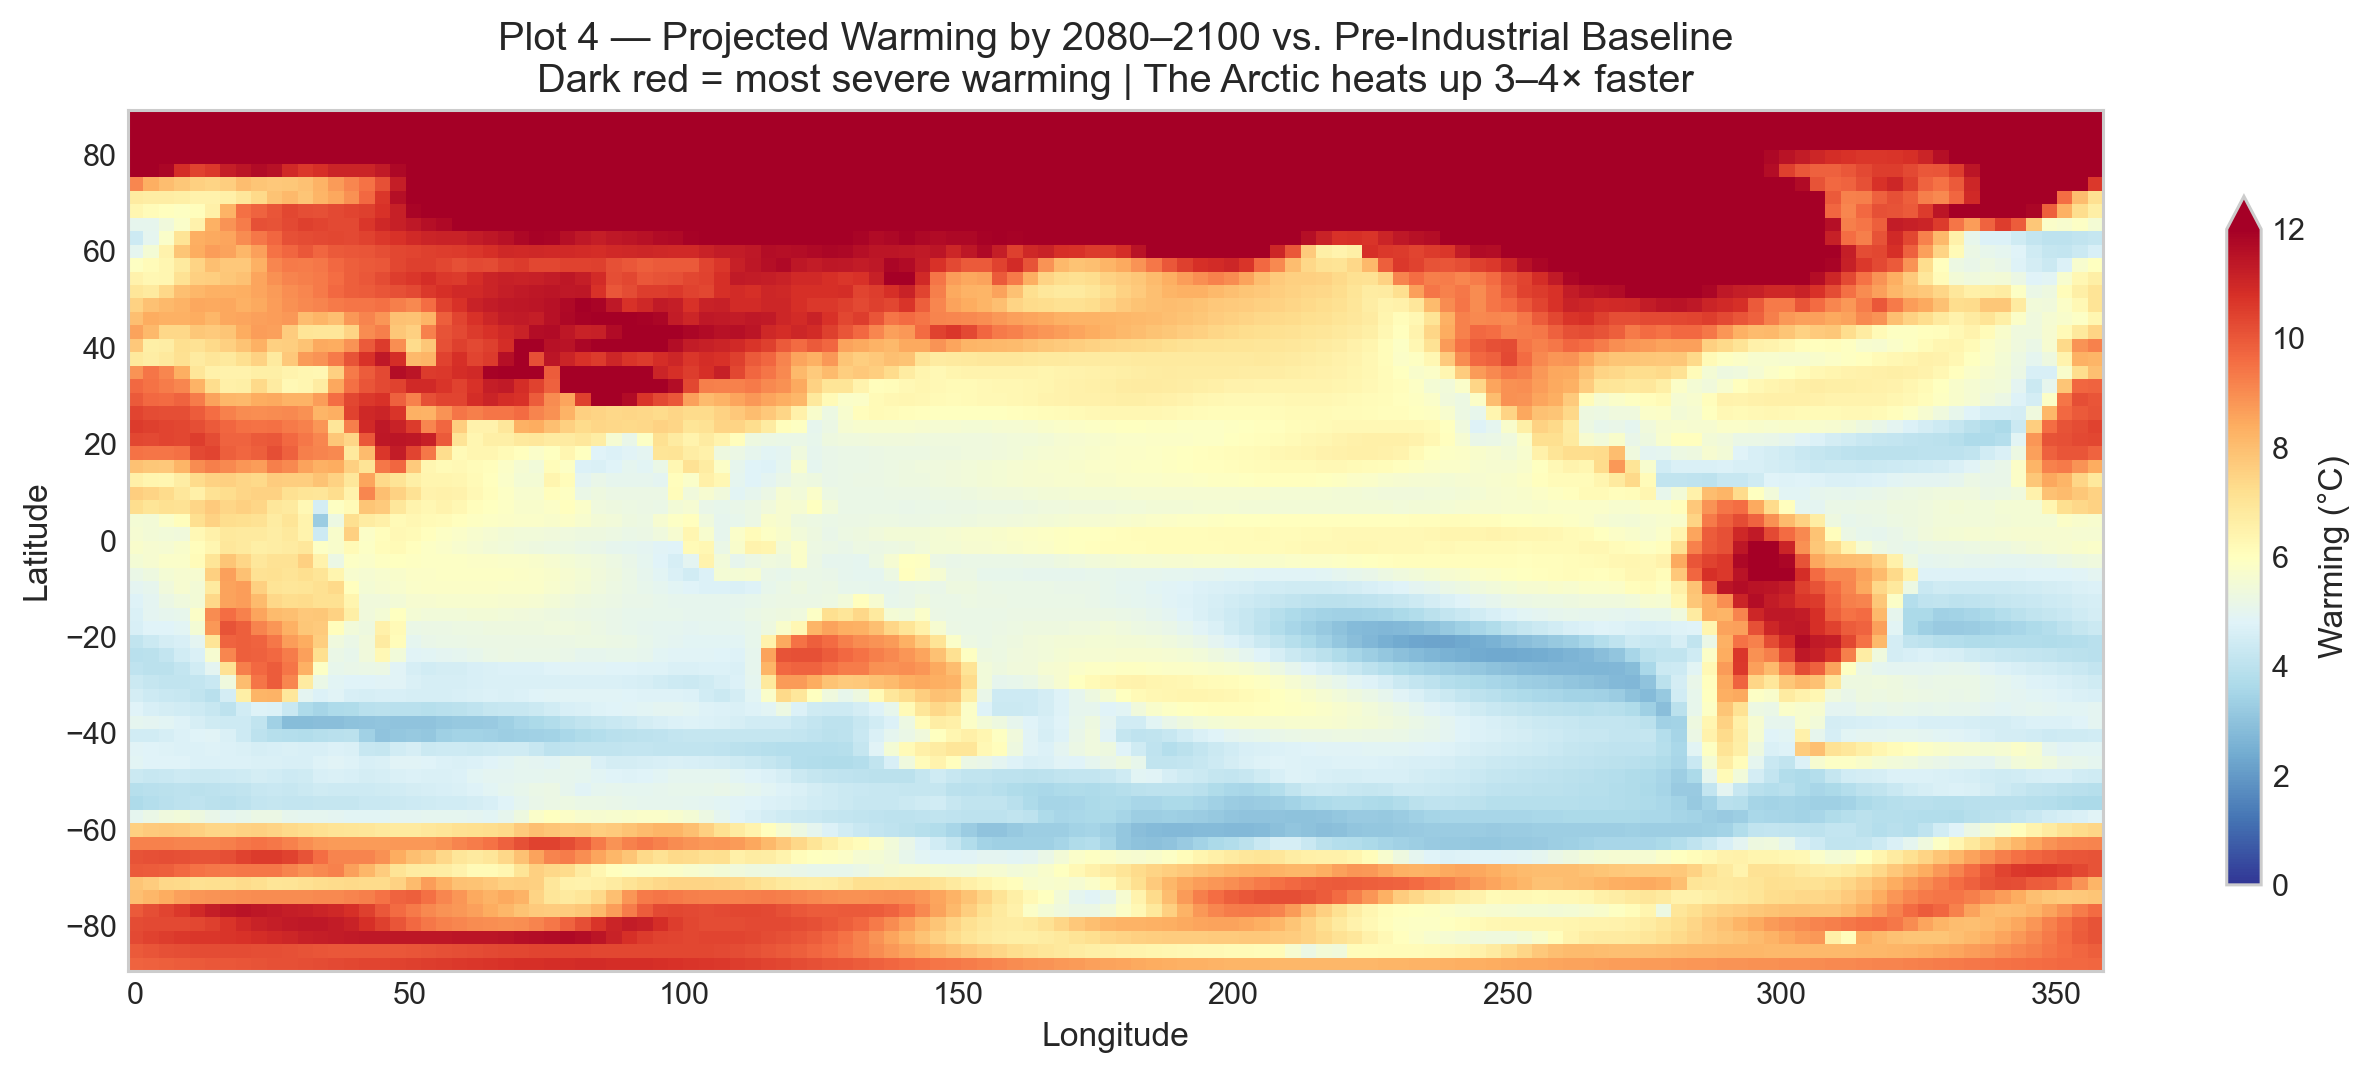

In [9]:
# Compute 20-year time-mean maps, then subtract to get the warming signal
baseline_map = ds_hist['tas'].sel(time=slice('1850', '1900')).mean('time') - 273.15
future_map   = ds_ssp['tas'].sel(time=slice('2080', '2100')).mean('time')  - 273.15
warming      = future_map - baseline_map

fig, ax = plt.subplots(figsize=(12, 5))
warming.plot(ax=ax, cmap='RdYlBu_r', vmin=0, vmax=12,
             cbar_kwargs={'label': 'Warming (°C)', 'shrink': 0.8})

ax.set_title('Plot 4 — Projected Warming by 2080–2100 vs. Pre-Industrial Baseline\n'
             'Dark red = most severe warming | The Arctic heats up 3–4× faster')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
### Impact Plot 3 — Arctic Sea Ice Is Disappearing
Sea-ice concentration (`siconc`) measures the fraction of the ocean covered by ice (0 = open water, 1 = fully frozen).
We look at **September** — the end of the summer melt season — when ice is at its lowest each year.

A disappearing Arctic in summer means **less sunlight reflected back to space**, speeding up warming further.

> ⏱ *Streams from Google Cloud — allow ~1–2 minutes.*

Loading sea-ice data...
  loaded siconc/historical: 1850-01 to 2014-12


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded siconc/ssp585: 2015-01 to 2300-12


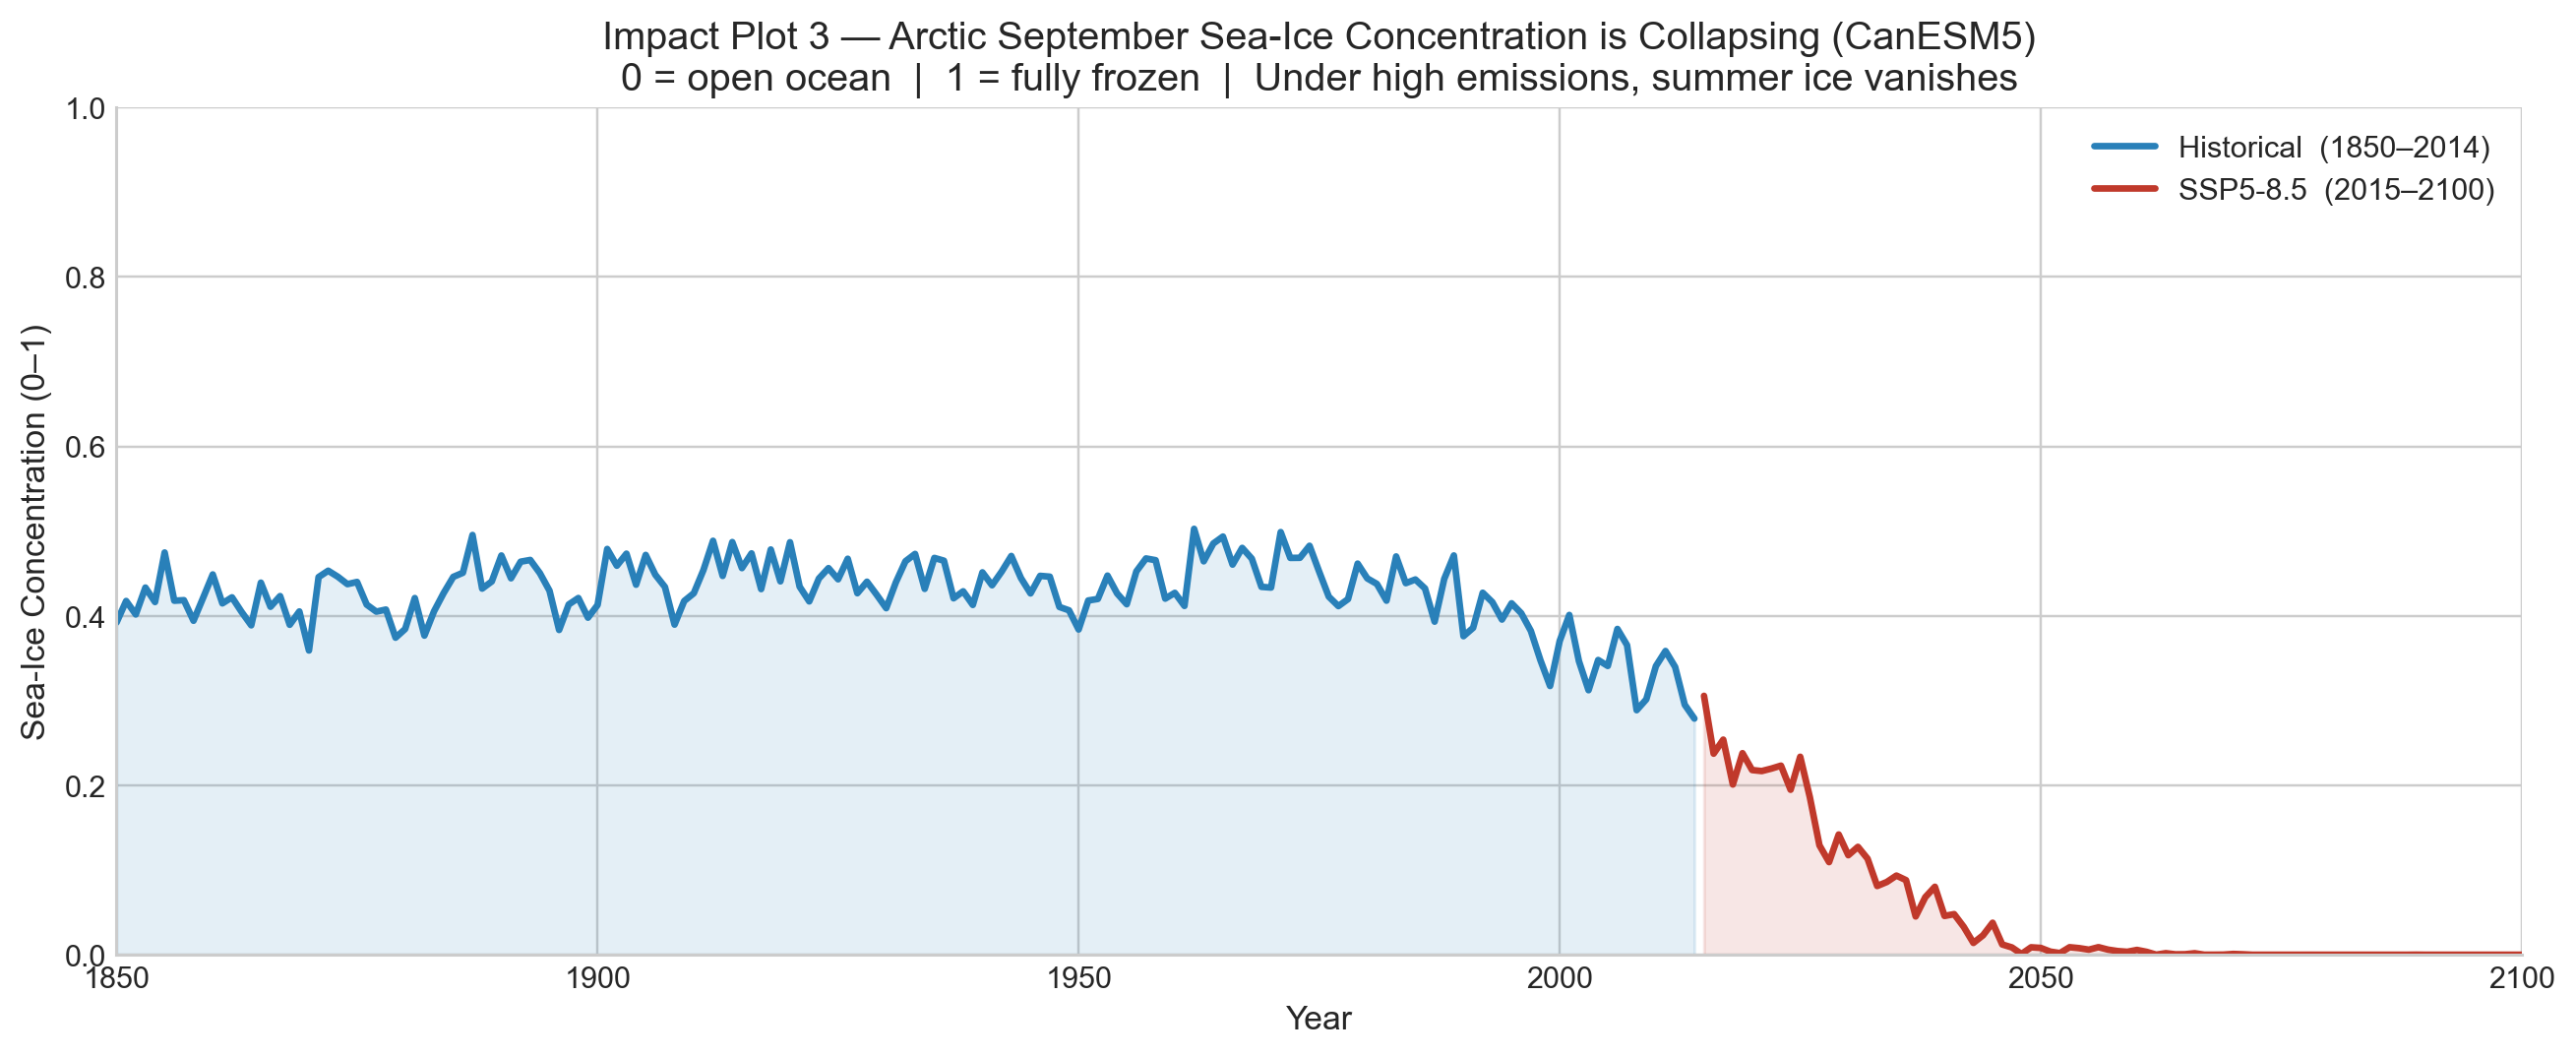

In [10]:
print('Loading sea-ice data...')
ds_ice_hist = open_cmip6('siconc', 'historical', table='SImon')
ds_ice_ssp  = open_cmip6('siconc', 'ssp585',     table='SImon')

fig, ax = plt.subplots(figsize=(12, 5))

for ds, color, label in [
    (ds_ice_hist, '#2980b9', 'Historical  (1850–2014)'),
    (ds_ice_ssp,  '#c0392b', 'SSP5-8.5  (2015–2100)'),
]:
    # Keep only September months (month index 9)
    sept = ds['siconc'].isel(time=(ds.time.dt.month == 9).values)

    # Latitude coordinate name differs across CMIP6 stores; detect it safely
    lat_name = next((c for c in sept.coords if 'lat' in c.lower()), None)
    if lat_name is None:
        raise ValueError('Could not find a latitude coordinate for sea-ice data.')
    arctic = sept.where(sept[lat_name] > 60)

    # Average over all spatial dimensions, then annual resample
    sp_dims = [d for d in arctic.dims if d != 'time']
    annual = arctic.mean(sp_dims).resample(time='YE').mean()

    years = np.array([int(str(t)[:4]) for t in annual.time.values])
    vals = annual.values.astype(float)

    # Some CMIP6 stores encode sea ice as percent (0-100), others as fraction (0-1)
    if np.nanmax(vals) > 1.5:
        vals = vals / 100.0

    if 'SSP5-8.5' in label:
        keep = years <= 2100
        years = years[keep]
        vals = vals[keep]

    ax.plot(years, vals, color=color, lw=2.2, label=label)
    ax.fill_between(years, 0, vals, alpha=0.12, color=color)

ax.set_xlim(1850, 2100)
ax.set_ylim(0, 1)
ax.set_title('Impact Plot 3 — Arctic September Sea-Ice Concentration is Collapsing (CanESM5)\n'
             '0 = open ocean  |  1 = fully frozen  |  Under high emissions, summer ice vanishes')
ax.set_xlabel('Year')
ax.set_ylabel('Sea-Ice Concentration (0–1)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 4 — Rainfall Patterns Are Shifting
Precipitation (`pr`) in kg m⁻² s⁻¹, converted to mm/day.
We compare the 2080–2100 future average against the 1980–2000 historical average.

- **Blue regions** = more rain/snow (flooding risk)
- **Brown regions** = less rain/snow (drought risk)

This "wet gets wetter, dry gets drier" pattern will stress agriculture and water supplies globally.

> ⏱ *Streams from Google Cloud — allow ~1–2 minutes.*

Loading precipitation data...
  loaded pr/historical: 1850-01 to 2014-12


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded pr/ssp585: 2015-01 to 2300-12


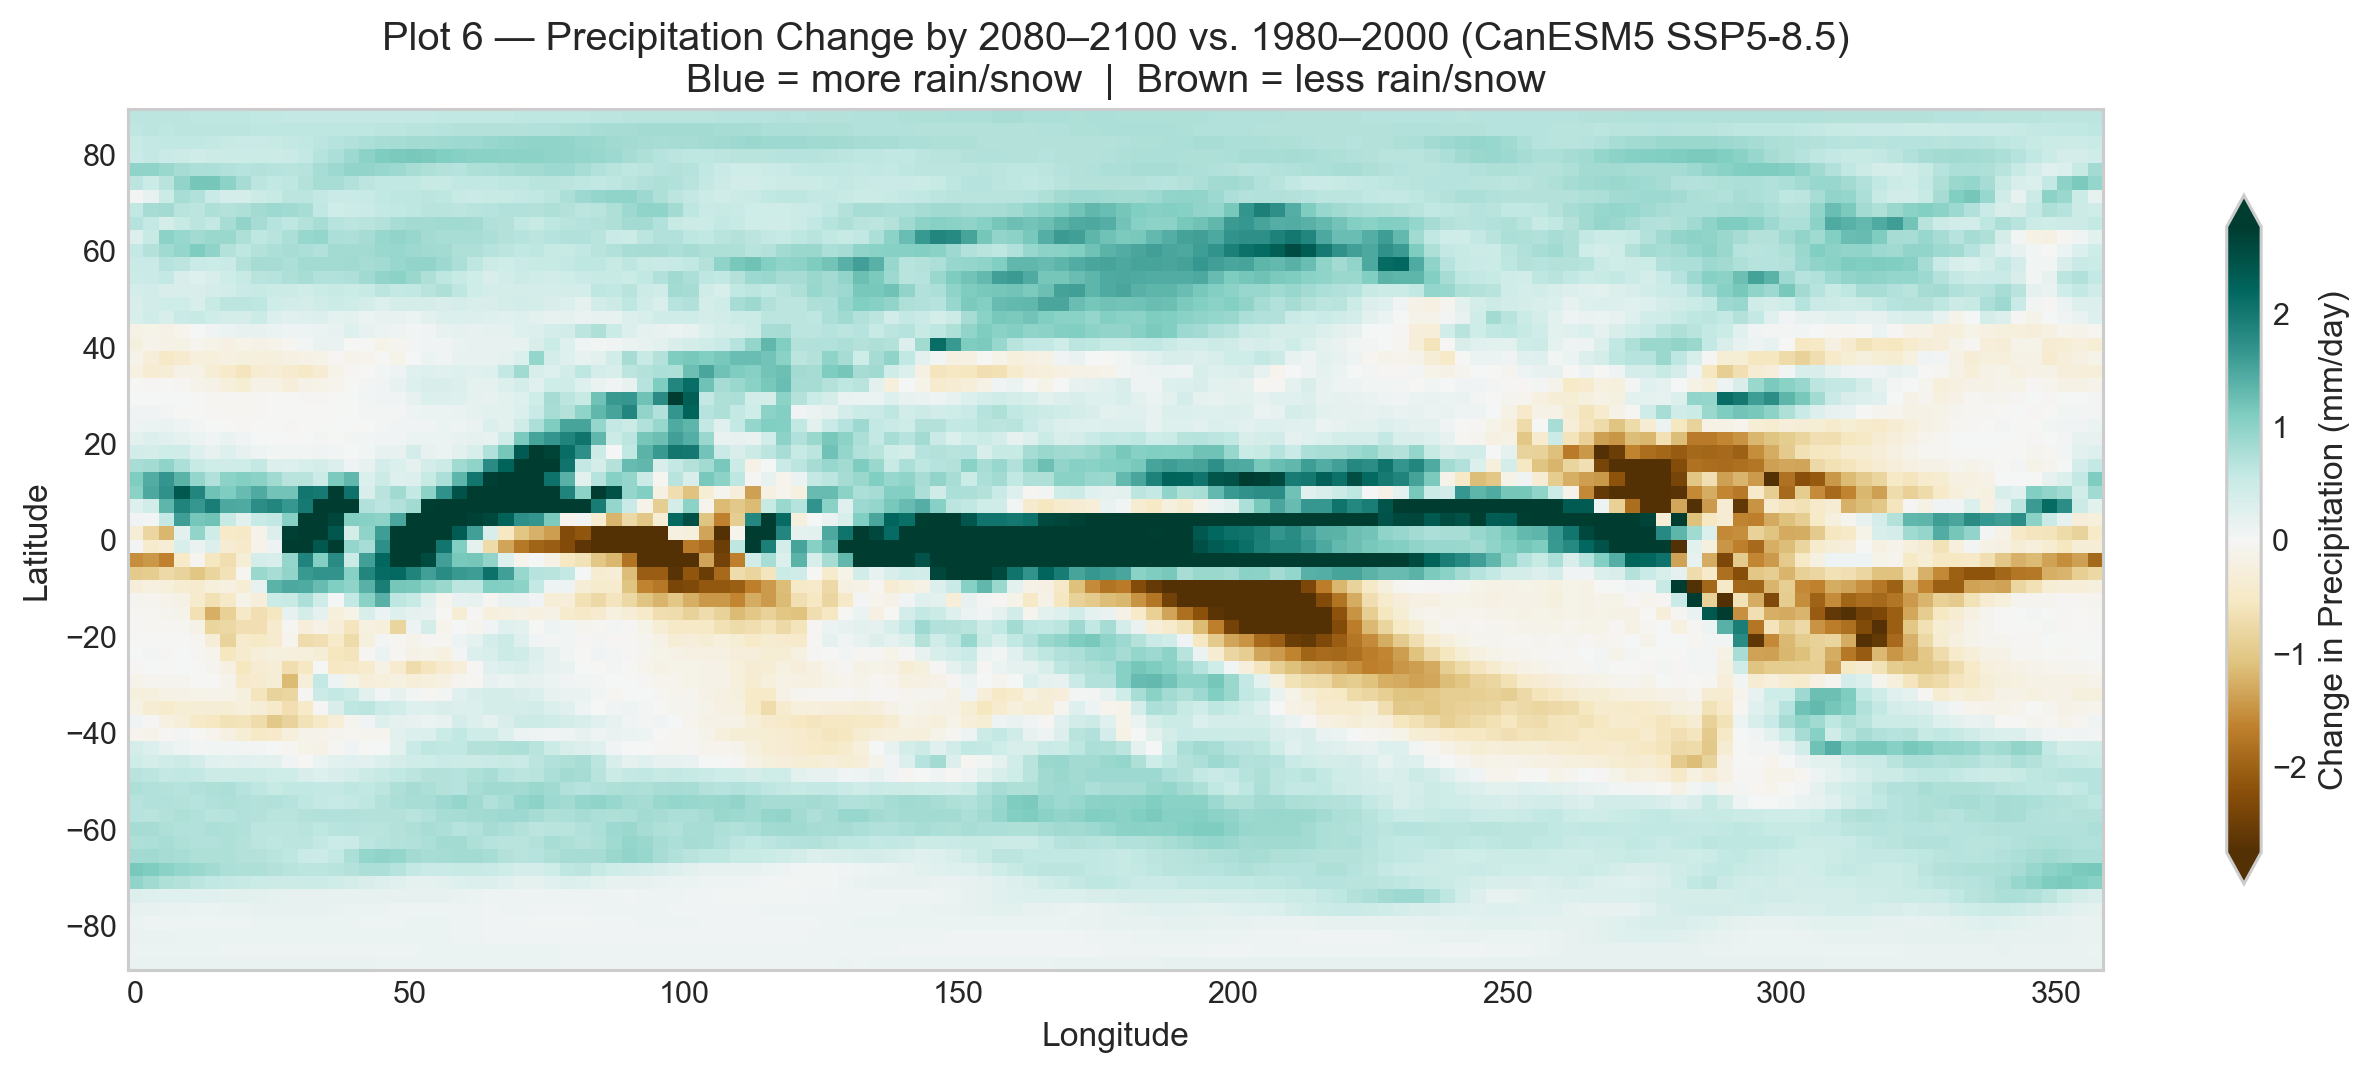

In [11]:
print('Loading precipitation data...')
ds_pr_hist = open_cmip6('pr', 'historical')
ds_pr_ssp  = open_cmip6('pr', 'ssp585')

# 20-year time mean for each period, unit conversion: kg/m²/s × 86400 = mm/day
pr_base   = ds_pr_hist['pr'].sel(time=slice('1980', '2000')).mean('time') * 86400
pr_future = ds_pr_ssp['pr'].sel(time=slice('2080', '2100')).mean('time')  * 86400
pr_change = pr_future - pr_base

# Symmetric colorbar: cap at 97th percentile so outliers don't wash out the map
vmax = float(abs(pr_change).quantile(0.97))

fig, ax = plt.subplots(figsize=(12, 5))
pr_change.plot(ax=ax, cmap='BrBG', vmin=-vmax, vmax=vmax,
               cbar_kwargs={'label': 'Change in Precipitation (mm/day)', 'shrink': 0.8})

ax.set_title('Plot 6 — Precipitation Change by 2080–2100 vs. 1980–2000 (CanESM5 SSP5-8.5)\n'
             'Blue = more rain/snow  |  Brown = less rain/snow')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
### Impact Plot 5 (Historical Only) — Arctic Sea-Ice Trend (Simple Line Plot)
**What this plot shows:**
A historical time series of Arctic September sea-ice concentration (annual values + smoothed trend).
It tracks how much of the Arctic Ocean remains ice-covered at summer minimum.

**How to read increase/decrease in this plot (y-axis = sea-ice concentration 0 to 1):**
- **Increase** in y-value -> more Arctic summer sea ice (less warming pressure).
- **Decrease** in y-value -> less Arctic summer sea ice (stronger warming signal).

**Why this matters for climate change:**
Persistent decline in sea ice is strong evidence of climate warming.
Less ice means lower albedo, so the ocean absorbs more heat and amplifies warming.

**Real-world negative impacts linked to decline:**
Faster Arctic warming, coastal erosion in northern communities, ecosystem disruption (ice-dependent species),
and additional influence on weather extremes through Arctic amplification.

**What negative values mean:**
This specific plot is concentration (0 to 1), so values are not negative.
If sea-ice anomaly were plotted, negative values would mean less ice than baseline.

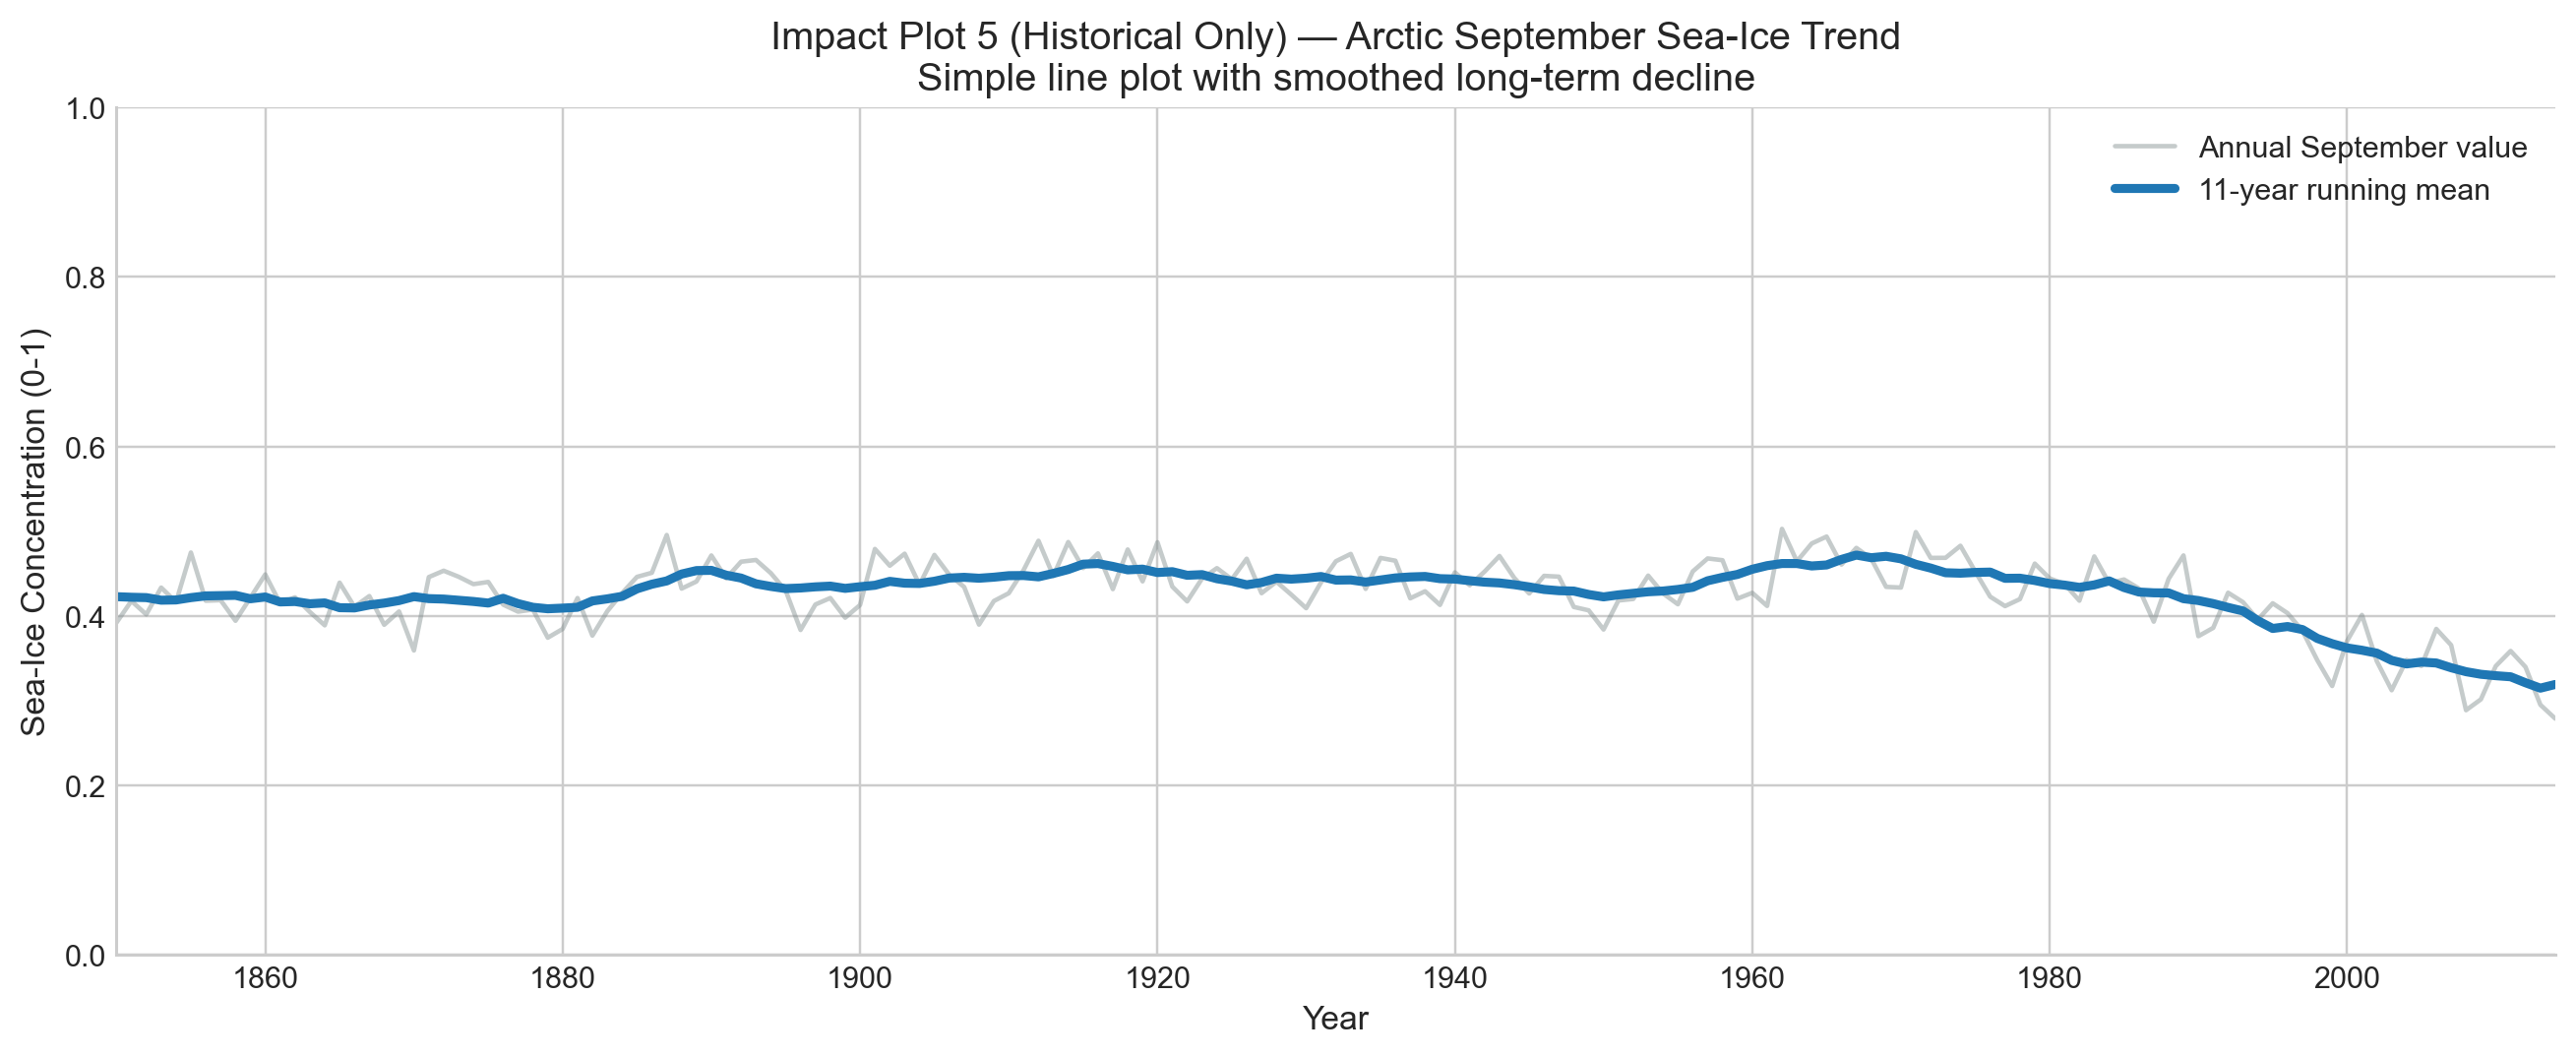

In [12]:
# Use already-loaded historical sea-ice data if available
try:
    ds_ice_hist
except NameError:
    ds_ice_hist = open_cmip6('siconc', 'historical', table='SImon')

ice_hist = ds_ice_hist['siconc']
sept_hist = ice_hist.isel(time=(ds_ice_hist.time.dt.month == 9).values)

lat_name = next((c for c in sept_hist.coords if 'lat' in c.lower()), None)
if lat_name is None:
    raise ValueError('Could not find a latitude coordinate for historical sea-ice data.')

arctic_hist = sept_hist.where(sept_hist[lat_name] > 60)
sp_dims = [d for d in arctic_hist.dims if d != 'time']
annual_ice = arctic_hist.mean(sp_dims).resample(time='YE').mean()

years_ice = np.array([int(str(t)[:4]) for t in annual_ice.time.values])
vals_ice = annual_ice.values.astype(float)

# Some CMIP6 stores encode sea ice as percent (0-100), others as fraction (0-1)
if np.nanmax(vals_ice) > 1.5:
    vals_ice = vals_ice / 100.0

smooth_ice = pd.Series(vals_ice).rolling(window=11, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_ice, vals_ice, color='#7f8c8d', alpha=0.45, lw=1.5, label='Annual September value')
ax.plot(years_ice, smooth_ice, color='#1f77b4', lw=3, label='11-year running mean')

ax.set_xlim(1850, 2014)
ax.set_ylim(0, 1)
ax.set_title('Impact Plot 5 (Historical Only) — Arctic September Sea-Ice Trend\n'
             'Simple line plot with smoothed long-term decline')
ax.set_xlabel('Year')
ax.set_ylabel('Sea-Ice Concentration (0-1)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 6 (Historical Only) — Global Precipitation Anomaly (Simple Line Plot)
**What this plot shows:**
A historical global mean precipitation anomaly relative to an 1850-1900 baseline.
It shows year-to-year variability and long-term shift in global precipitation.

**How to read increase/decrease in this plot (y-axis = precipitation anomaly, mm/day):**
- **Increase** in y-value (more positive) -> wetter-than-baseline global mean conditions.
- **Decrease** in y-value (more negative) -> drier-than-baseline global mean conditions.

**Why this matters for climate change:**
Warming intensifies the water cycle, changing rainfall intensity and distribution.
A shifting anomaly indicates climate-driven hydroclimate change.

**Real-world negative impacts linked to large shifts:**
Higher flood risk in wetter regions, stronger drought risk in drying regions,
crop stress, water-supply instability, and infrastructure stress from extremes.

**What negative values mean:**
Negative values mean global precipitation is below the 1850-1900 baseline average.

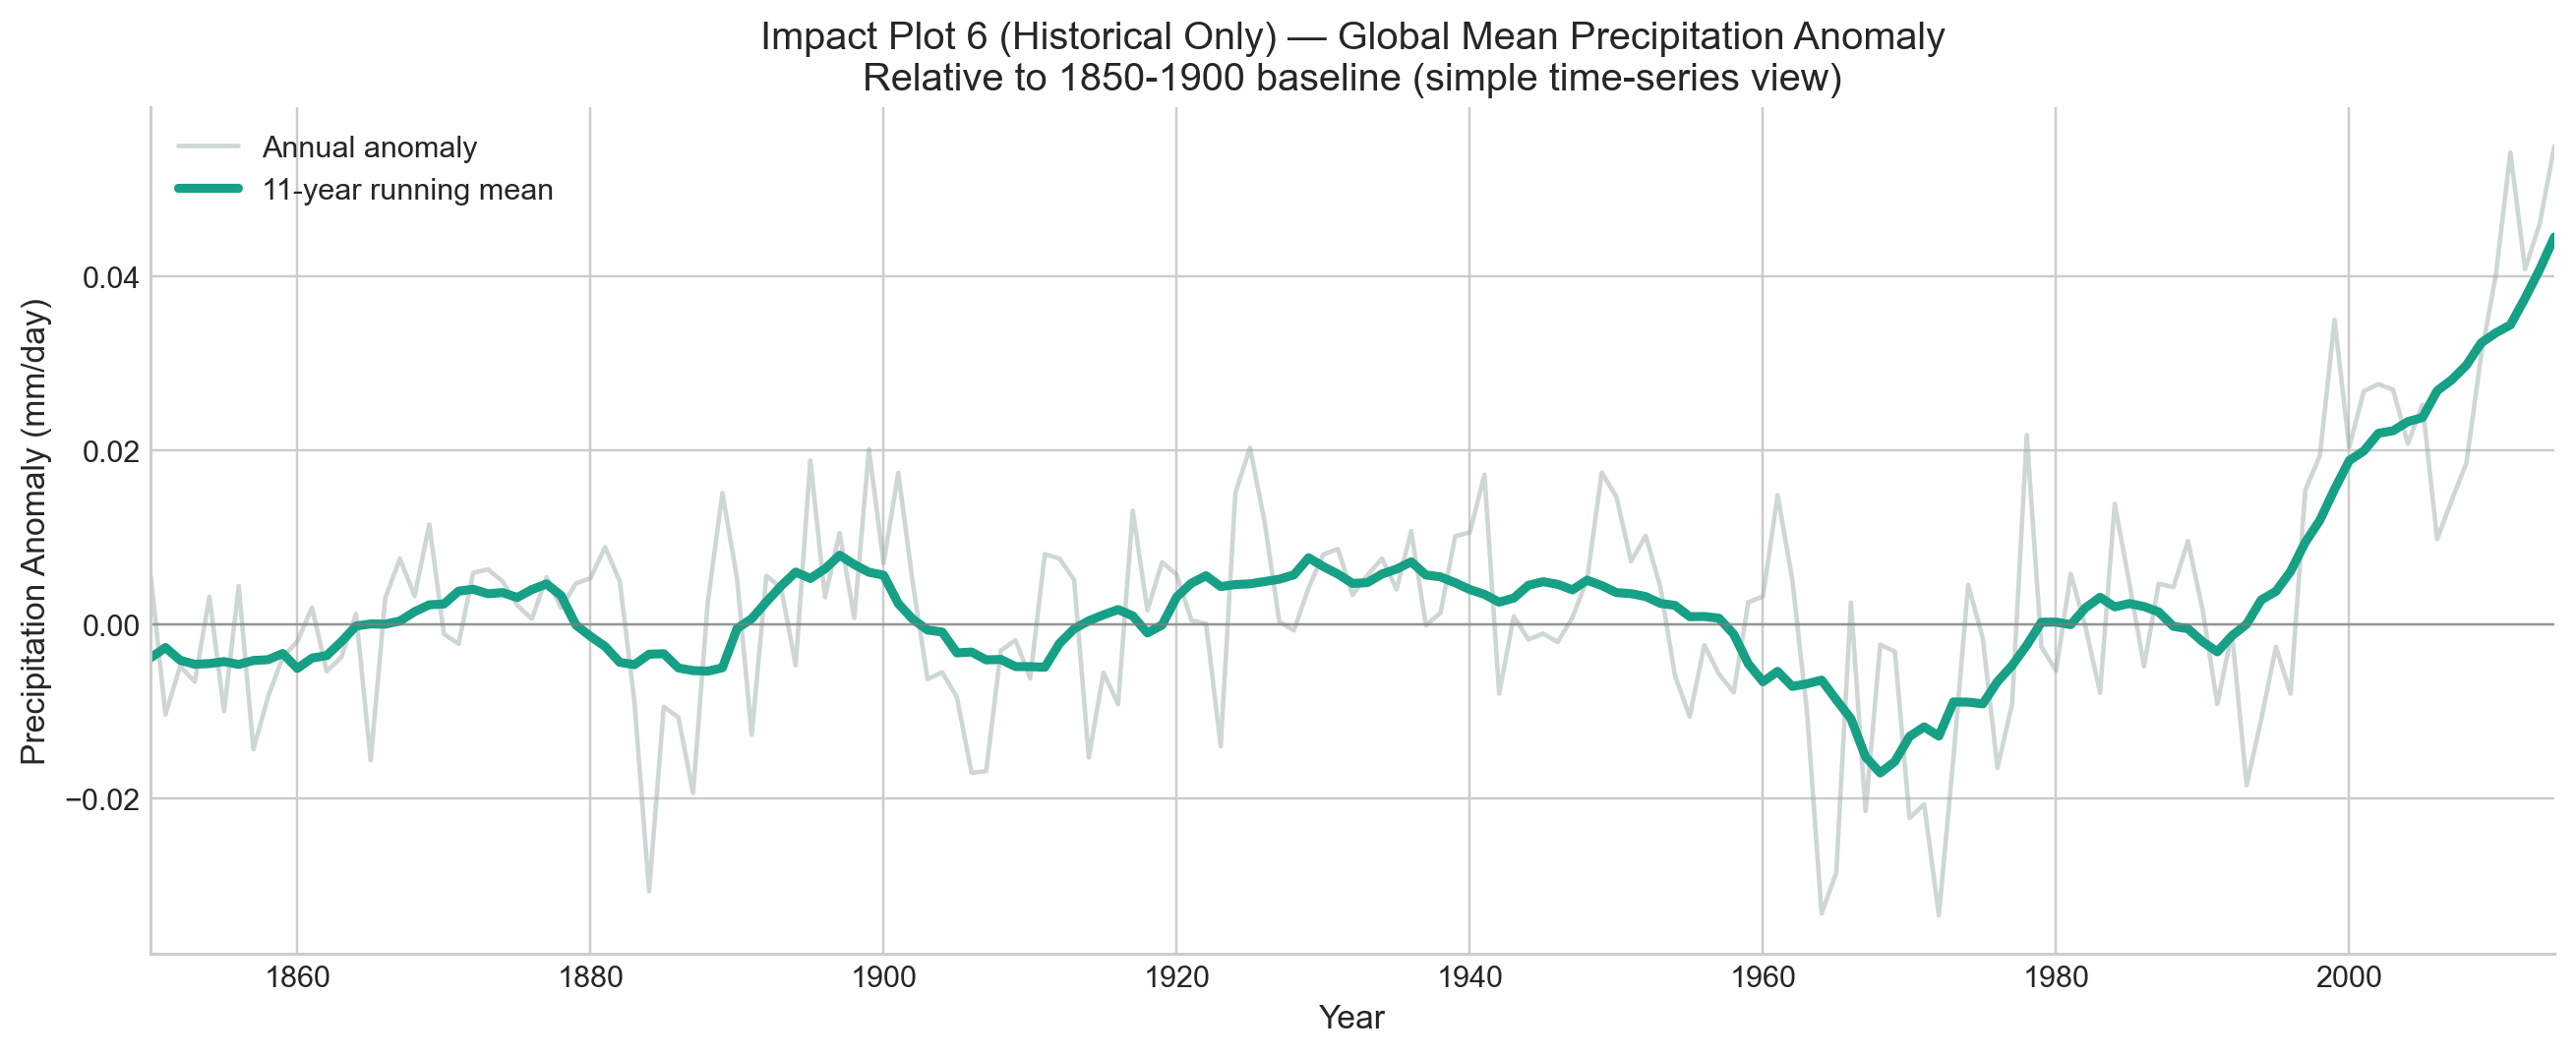

In [13]:
# Use already-loaded historical precipitation if available
try:
    ds_pr_hist
except NameError:
    ds_pr_hist = open_cmip6('pr', 'historical')

# Convert from kg m^-2 s^-1 to mm/day
pr_hist = ds_pr_hist['pr'] * 86400

# Global mean precipitation time series
lat_name = next((c for c in pr_hist.coords if 'lat' in c.lower()), None)
if lat_name is None:
    raise ValueError('Could not find a latitude coordinate for historical precipitation data.')

weights = np.cos(np.deg2rad(pr_hist[lat_name]))
weights.name = 'weights'
pr_global = pr_hist.weighted(weights).mean([d for d in pr_hist.dims if d != 'time']).resample(time='YE').mean()

years_pr = np.array([int(str(t)[:4]) for t in pr_global.time.values])
vals_pr = pr_global.values.astype(float)

baseline_pr = float(pd.Series(vals_pr, index=years_pr).loc[1850:1900].mean())
anom_pr = vals_pr - baseline_pr
smooth_pr = pd.Series(anom_pr).rolling(window=11, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_pr, anom_pr, color='#95a5a6', alpha=0.45, lw=1.5, label='Annual anomaly')
ax.plot(years_pr, smooth_pr, color='#16a085', lw=3, label='11-year running mean')
ax.axhline(0, color='gray', lw=0.8, alpha=0.7)

ax.set_xlim(1850, 2014)
ax.set_title('Impact Plot 6 (Historical Only) — Global Mean Precipitation Anomaly\n'
             'Relative to 1850-1900 baseline (simple time-series view)')
ax.set_xlabel('Year')
ax.set_ylabel('Precipitation Anomaly (mm/day)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 7 — Arctic Sea-Ice Across SSP Pathways (Line Plot)
**What this plot shows:**
A comparison of Arctic September sea-ice concentration across historical + SSP1-2.6, SSP2-4.5, SSP5-8.5.
It shows how sea-ice loss changes under different future emissions pathways.

**How to read increase/decrease in this plot (y-axis = sea-ice concentration 0 to 1):**
- **Higher y-values** -> more remaining sea ice (lower climate damage risk in Arctic systems).
- **Lower y-values** -> less remaining sea ice (greater climate damage risk).

**Why this matters for climate change:**
It links emissions pathway choices directly to cryosphere outcomes.
Lower-emissions pathways keep more sea ice than high-emissions pathways.

**Real-world negative impacts when lines decline strongly:**
Greater Arctic amplification, ecosystem loss, Indigenous/community impacts, sea-route/geopolitical risks,
and added global climate feedback from reduced reflectivity.

**What negative values mean:**
This concentration plot does not use negative values.
If sea-ice anomaly were used, negative values would mean below-baseline ice.

Loading sea-ice SSP datasets...


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded siconc/ssp126: 2015-01 to 2300-12
  loaded siconc/ssp245: 2015-01 to 2100-12


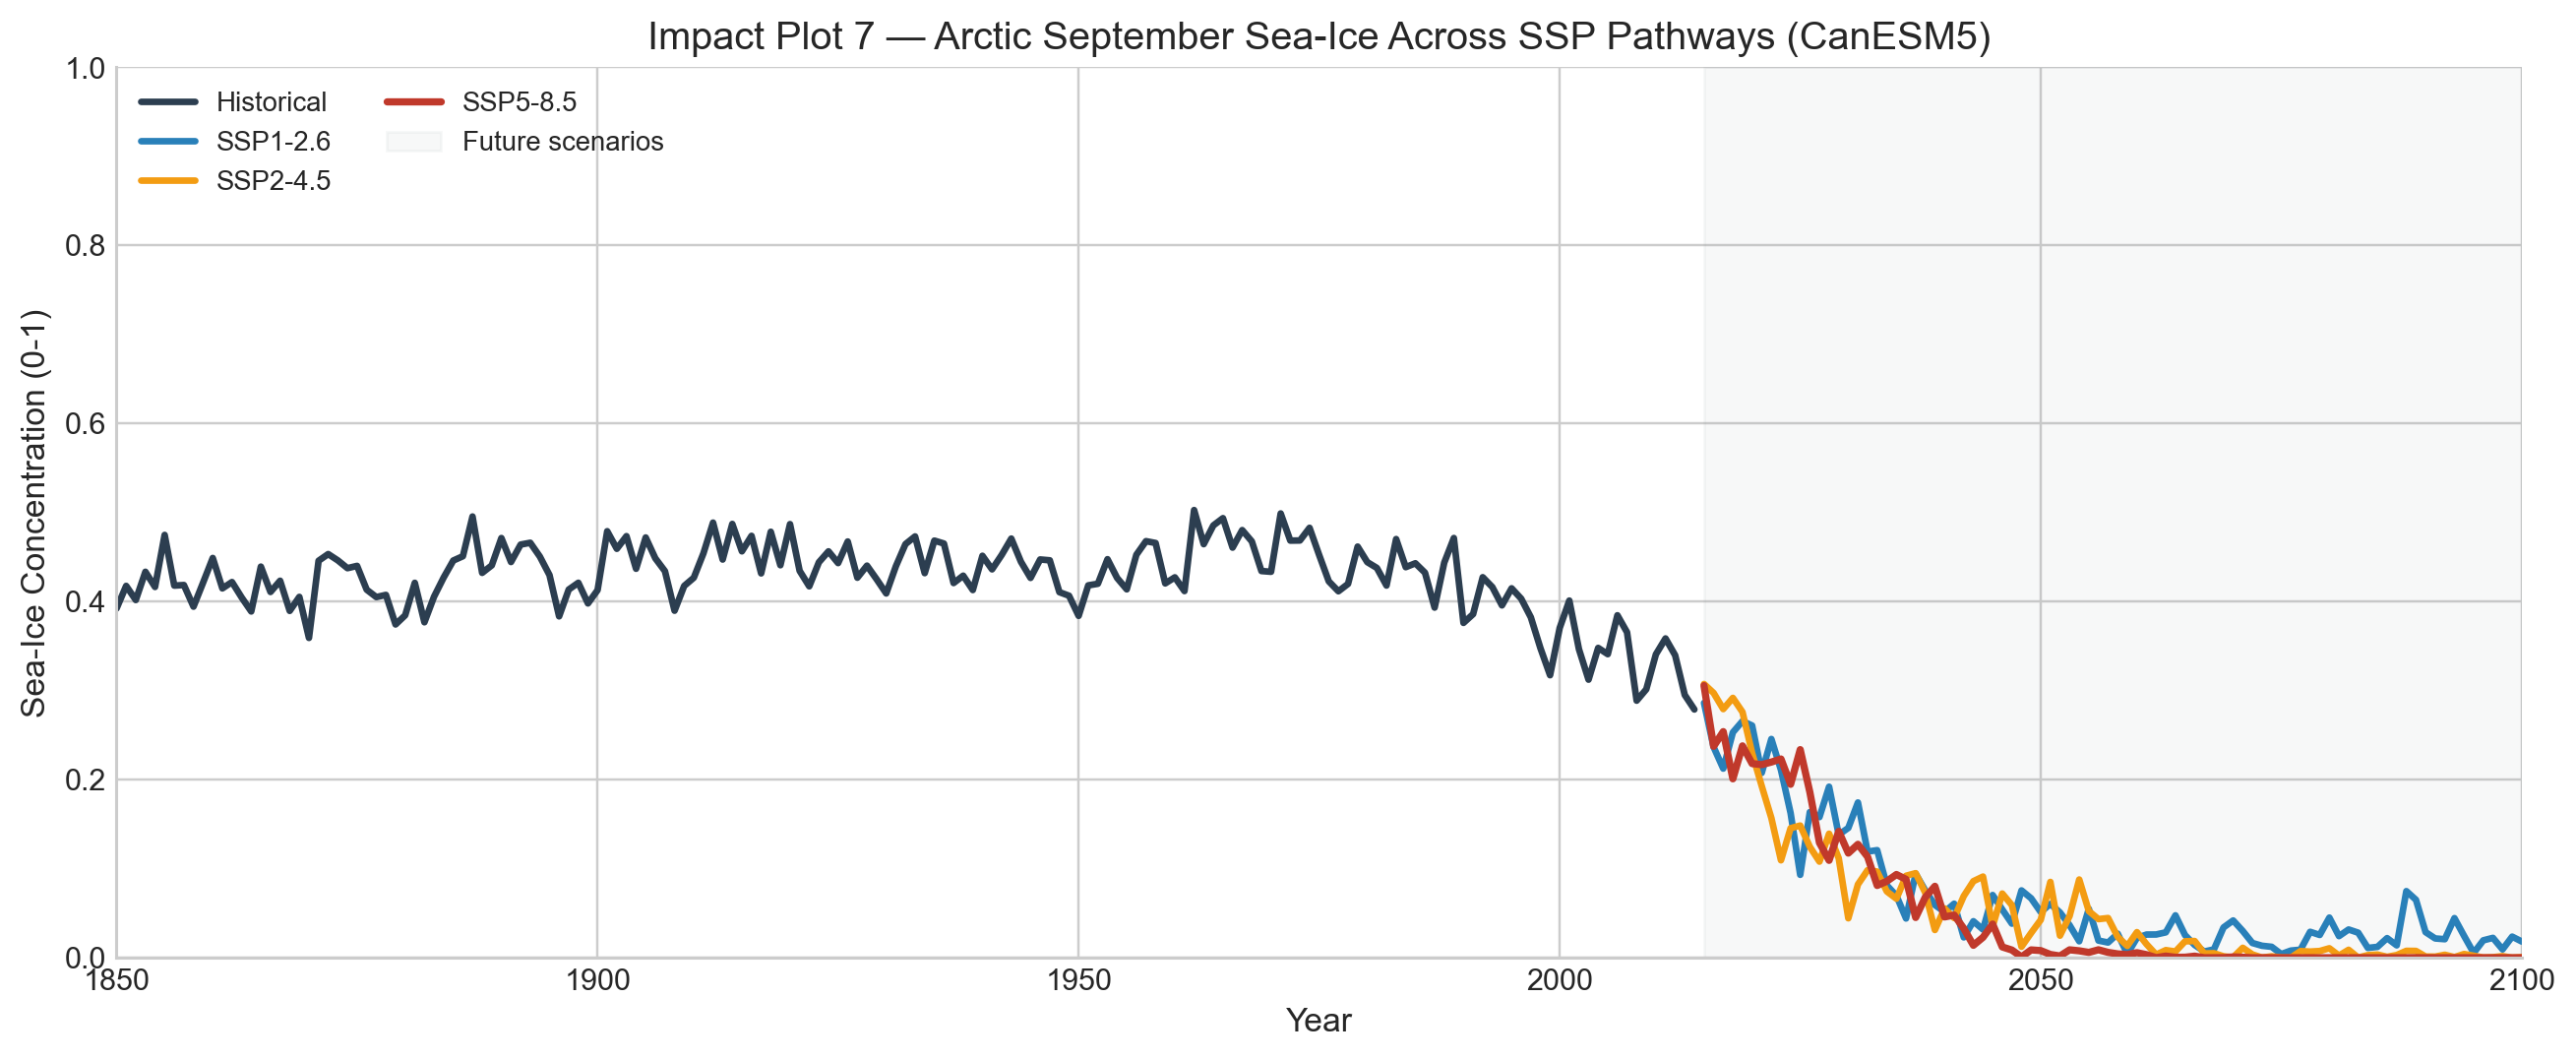

In [14]:
# Reuse historical/ssp585 sea-ice datasets if available
try:
    ds_ice_hist
except NameError:
    ds_ice_hist = open_cmip6('siconc', 'historical', table='SImon')
try:
    ds_ice_ssp
except NameError:
    ds_ice_ssp = open_cmip6('siconc', 'ssp585', table='SImon')

# Load additional SSP sea-ice runs
print('Loading sea-ice SSP datasets...')
ds_ice_ssp126 = open_cmip6('siconc', 'ssp126', table='SImon')
ds_ice_ssp245 = open_cmip6('siconc', 'ssp245', table='SImon')

def arctic_sept_series(ds):
    siconc = ds['siconc']
    sept = siconc.isel(time=(ds.time.dt.month == 9).values)
    lat_name = next((c for c in sept.coords if 'lat' in c.lower()), None)
    if lat_name is None:
        raise ValueError('Could not find latitude coordinate for sea-ice dataset.')
    arctic = sept.where(sept[lat_name] > 60)
    dims = [d for d in arctic.dims if d != 'time']
    annual = arctic.mean(dims).resample(time='YE').mean()
    years = np.array([int(str(t)[:4]) for t in annual.time.values])
    vals = annual.values.astype(float)
    if np.nanmax(vals) > 1.5:
        vals = vals / 100.0
    return years, vals

y_hist, v_hist   = arctic_sept_series(ds_ice_hist)
y_126, v_126     = arctic_sept_series(ds_ice_ssp126)
y_245, v_245     = arctic_sept_series(ds_ice_ssp245)
y_585, v_585     = arctic_sept_series(ds_ice_ssp)

# Keep future scenarios through 2100 only
keep126 = y_126 <= 2100
keep245 = y_245 <= 2100
keep585 = y_585 <= 2100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_hist, v_hist, color='#2c3e50', lw=2.2, label='Historical')
ax.plot(y_126[keep126], v_126[keep126], color='#2980b9', lw=2.2, label='SSP1-2.6')
ax.plot(y_245[keep245], v_245[keep245], color='#f39c12', lw=2.2, label='SSP2-4.5')
ax.plot(y_585[keep585], v_585[keep585], color='#c0392b', lw=2.4, label='SSP5-8.5')

ax.axvspan(2015, 2100, alpha=0.06, color='#7f8c8d', label='Future scenarios')
ax.set_xlim(1850, 2100)
ax.set_ylim(0, 1)
ax.set_title('Impact Plot 7 — Arctic September Sea-Ice Across SSP Pathways (CanESM5)')
ax.set_xlabel('Year')
ax.set_ylabel('Sea-Ice Concentration (0-1)')
ax.legend(ncol=2, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Impact Plot 8 — Global Precipitation Across SSP Pathways (Line Plot)
**What this plot shows:**
A comparison of global mean precipitation anomaly across historical + SSP1-2.6, SSP2-4.5, SSP5-8.5.
All curves are relative to the same 1850-1900 baseline.

**How to read increase/decrease in this plot (y-axis = precipitation anomaly, mm/day):**
- **Increase** in y-value -> global mean precipitation rises above baseline (wetter signal).
- **Decrease** in y-value -> global mean precipitation falls below baseline (drier signal).

**Why this matters for climate change:**
Different SSP pathways produce different water-cycle responses.
Bigger divergence by 2100 means emissions choices strongly affect hydroclimate outcomes.

**Real-world negative impacts linked to strong positive/negative shifts:**
More intense rainfall and flooding in some regions, deeper drying and drought in others,
food-system volatility, water-security stress, and higher adaptation costs.

**What negative values mean:**
Negative anomaly values mean precipitation is below baseline (drier-than-baseline conditions).

Loading precipitation SSP datasets...


/var/folders/jc/zlyx5cfj47b4kf9kgt678kkc0000gn/T/ipykernel_24914/2130042991.py:17: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(gcs.get_mapper(row.zstore.values[0]), consolidated=True)


  loaded pr/ssp126: 2015-01 to 2300-12
  loaded pr/ssp245: 2015-01 to 2100-12


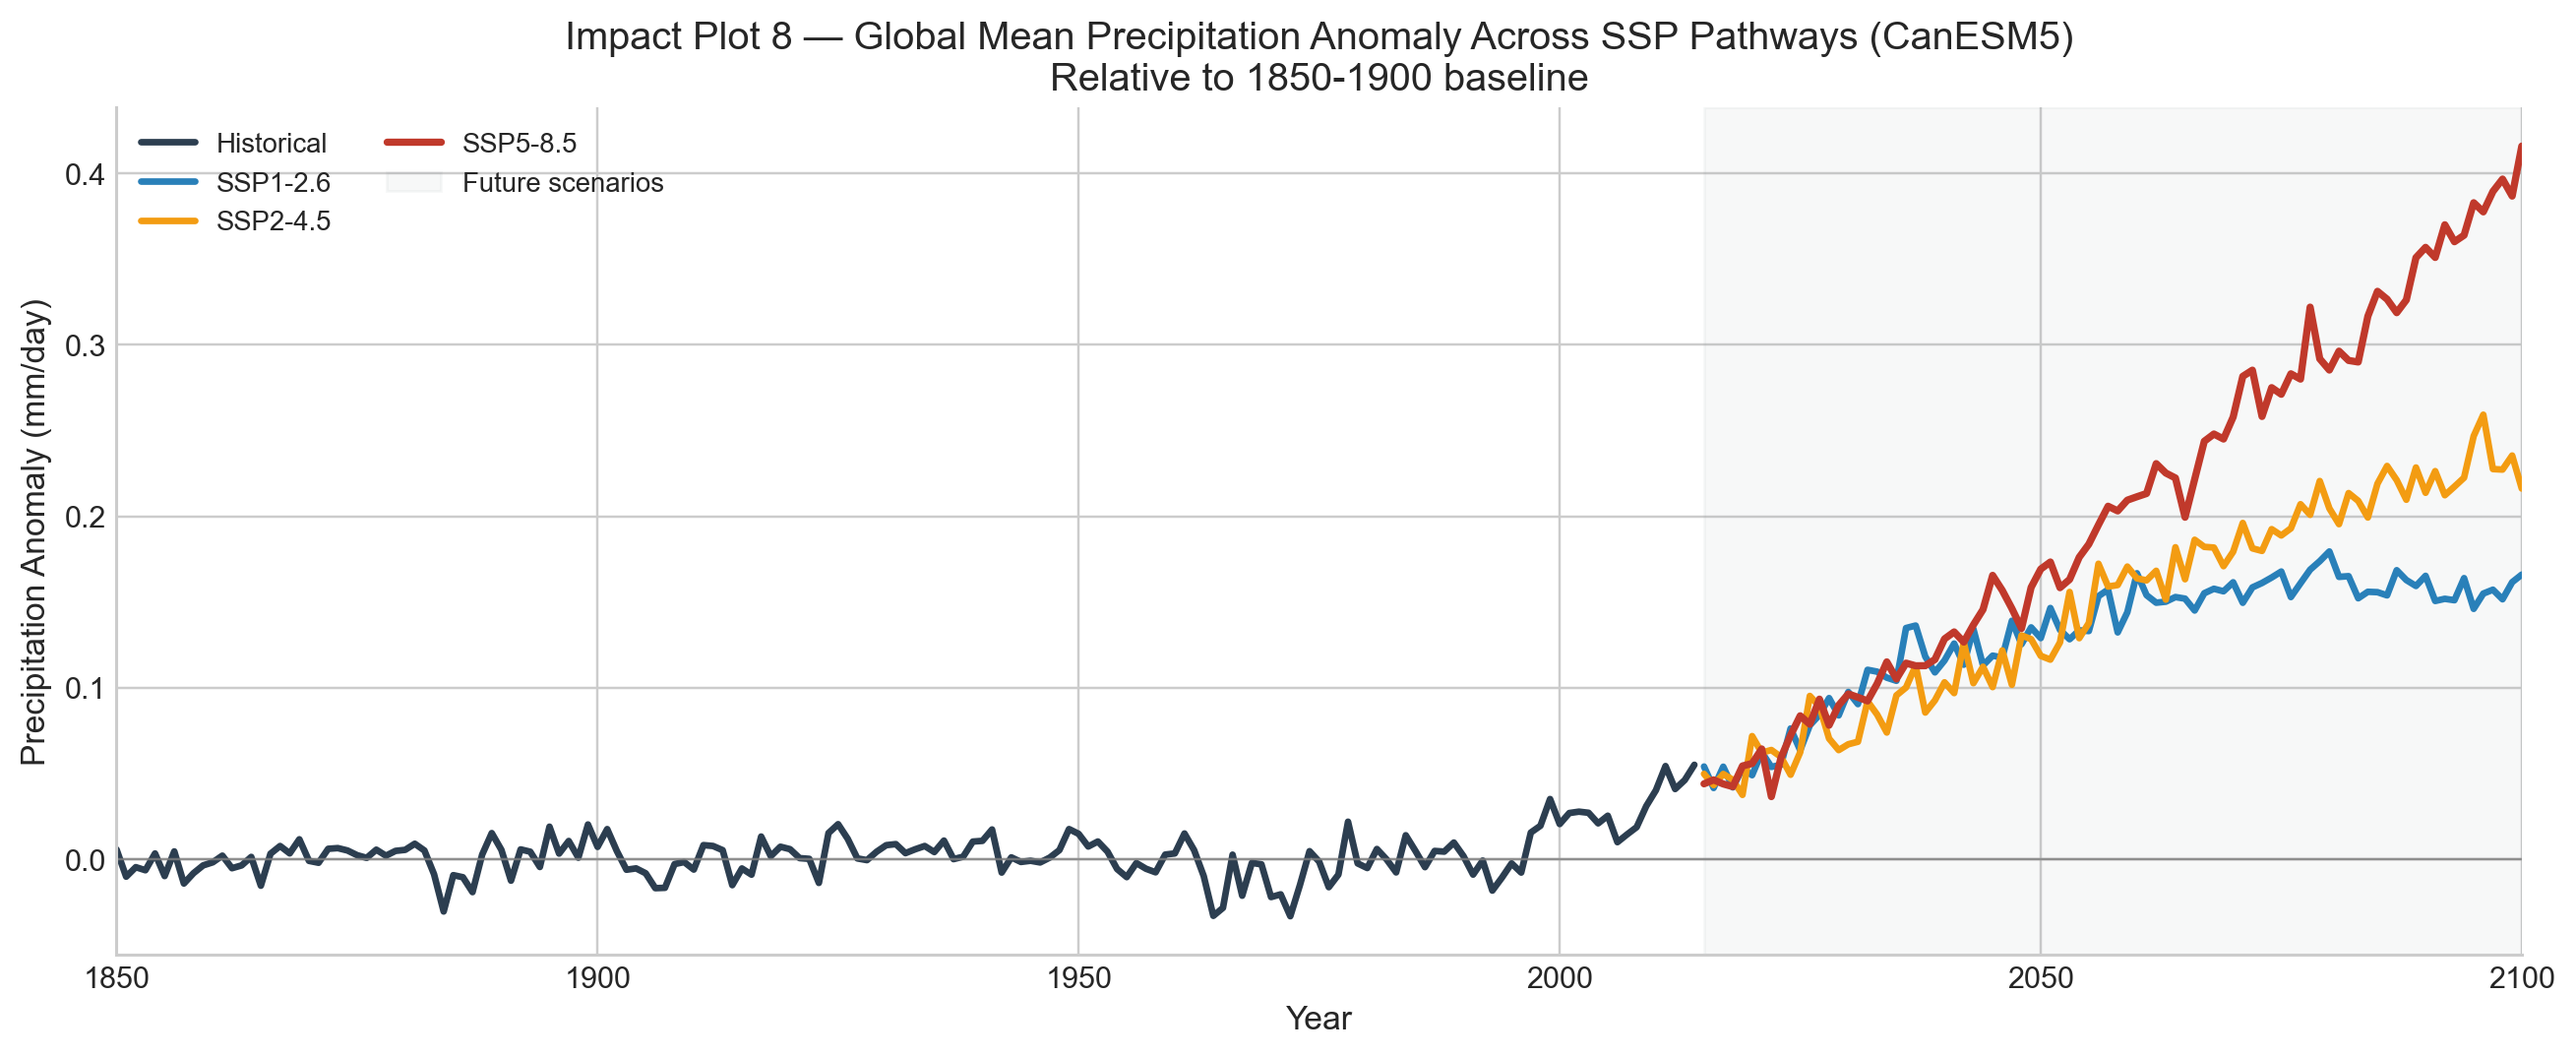

In [15]:
# Reuse historical/ssp585 precipitation datasets if available
try:
    ds_pr_hist
except NameError:
    ds_pr_hist = open_cmip6('pr', 'historical')
try:
    ds_pr_ssp
except NameError:
    ds_pr_ssp = open_cmip6('pr', 'ssp585')

print('Loading precipitation SSP datasets...')
ds_pr_ssp126 = open_cmip6('pr', 'ssp126')
ds_pr_ssp245 = open_cmip6('pr', 'ssp245')

def global_pr_series(ds):
    pr = ds['pr'] * 86400  # mm/day
    lat_name = next((c for c in pr.coords if 'lat' in c.lower()), None)
    if lat_name is None:
        raise ValueError('Could not find latitude coordinate for precipitation dataset.')
    w = np.cos(np.deg2rad(pr[lat_name]))
    w.name = 'weights'
    gm = pr.weighted(w).mean([d for d in pr.dims if d != 'time']).resample(time='YE').mean()
    years = np.array([int(str(t)[:4]) for t in gm.time.values])
    vals = gm.values.astype(float)
    return years, vals

y_pr_hist, v_pr_hist = global_pr_series(ds_pr_hist)
y_pr_126, v_pr_126 = global_pr_series(ds_pr_ssp126)
y_pr_245, v_pr_245 = global_pr_series(ds_pr_ssp245)
y_pr_585, v_pr_585 = global_pr_series(ds_pr_ssp)

# Baseline from historical 1850-1900 global mean
baseline_pr_ssp = float(pd.Series(v_pr_hist, index=y_pr_hist).loc[1850:1900].mean())
a_hist = v_pr_hist - baseline_pr_ssp
a_126 = v_pr_126 - baseline_pr_ssp
a_245 = v_pr_245 - baseline_pr_ssp
a_585 = v_pr_585 - baseline_pr_ssp

k126 = y_pr_126 <= 2100
k245 = y_pr_245 <= 2100
k585 = y_pr_585 <= 2100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_pr_hist, a_hist, color='#2c3e50', lw=2.2, label='Historical')
ax.plot(y_pr_126[k126], a_126[k126], color='#2980b9', lw=2.2, label='SSP1-2.6')
ax.plot(y_pr_245[k245], a_245[k245], color='#f39c12', lw=2.2, label='SSP2-4.5')
ax.plot(y_pr_585[k585], a_585[k585], color='#c0392b', lw=2.4, label='SSP5-8.5')

ax.axhline(0, color='gray', lw=0.8, alpha=0.8)
ax.axvspan(2015, 2100, alpha=0.06, color='#7f8c8d', label='Future scenarios')
ax.set_xlim(1850, 2100)
ax.set_title('Impact Plot 8 — Global Mean Precipitation Anomaly Across SSP Pathways (CanESM5)\n'
             'Relative to 1850-1900 baseline')
ax.set_xlabel('Year')
ax.set_ylabel('Precipitation Anomaly (mm/day)')
ax.legend(ncol=2, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Research Question

Based on the plots above:

- **Exploratory (not counted)**: the first two plots confirm strong dataset coverage across scenarios and variables (`tas`, `pr`, `siconc`).
- **Impact Plot 1** shows CanESM5 warming to roughly ~4–5°C by 2100 under SSP5-8.5, above Paris targets.
- **Impact Plot 2** shows unequal warming, with strong polar amplification in the Arctic.
- **Impact Plot 3** shows large declines in Arctic summer sea ice under high emissions.
- **Impact Plot 4** shows major future shifts in precipitation (drought/flood risk patterns).
- **Impact Plot 5 (historical only)** shows a clear long-term Arctic September sea-ice decline in a simple line trend.
- **Impact Plot 6 (historical only)** shows historical global precipitation anomaly trends in a simple line plot.

> **Question:** *How do global near-surface temperature projections from CMIP6 models differ across emission scenarios (SSP1-2.6, SSP2-4.5, SSP5-8.5) through 2100, and which regions and climate variables show the most dramatic change?*

---
### Bonus Plot 1 — When Do We Cross the Paris Agreement Thresholds?

**What the plot shows:**
This visualization tracks global mean temperature anomalies across four pathways: historical observations (1850–2014) plus three future SSP scenarios from 2015–2100. It includes three dashed lines representing climate policy targets: 1.5°C (Paris goal), 2.0°C (Paris limit), and 3.0°C (high-risk threshold).

**How to read warming (y-axis direction):**
- **Upward trend** = planet warming faster than the 1850–1900 baseline
- **Above 1.5°C line** = Paris 1.5°C goal exceeded
- **Above 2.0°C line** = Paris 2.0°C limit breached
- **SSP1-2.6 (blue)**: Stays near or below 2°C → strong climate mitigation works
- **SSP2-4.5 (orange)**: Crosses 2.0°C around 2040 → intermediate emissions still exceed Paris targets
- **SSP5-8.5 (red)**: Surpasses 4°C by 2100 → high emissions lead to extreme warming

**Why this matters for climate change:**
The Paris Agreement targets represent negotiated limits to protect ecosystems and human societies from worst-case impacts. At 1.5°C, Arctic summer sea ice survives longer, coral reefs face lower bleaching stress, and vulnerable regions (Small Island States) remain viable. At 2.0°C, these thresholds degrade further. At 3°C+, many regions face compound crises—drought, heat, floods, migration.

**Real-world negative impacts of crossing thresholds:**
- **1.5°C → 2.0°C**: Amazon rainforest accelerates toward savanna state; permafrost collapses release methane; island nations face existential flooding from sea-level rise.
- **2.0°C → 3.0°C**: Crop yields drop 10–20% globally; heat waves become unsurvivable in wet-bulb conditions (wet-bulb >35°C); freshwater aquifers deplete.
- **Above 3.0°C**: Mass climate migration; institutional collapse in vulnerable regions; extinction accelerates across 30%+ of species.

**What the y-axis values mean:**
The y-axis shows **temperature anomaly in °C relative to 1850–1900 pre-industrial baseline**. A value of +2.0 means the planet is 2°C warmer than it was before industrialization. We're already ~1.3°C warmer than that baseline (as of 2024), so crossing 1.5°C is imminent under all scenarios shown.

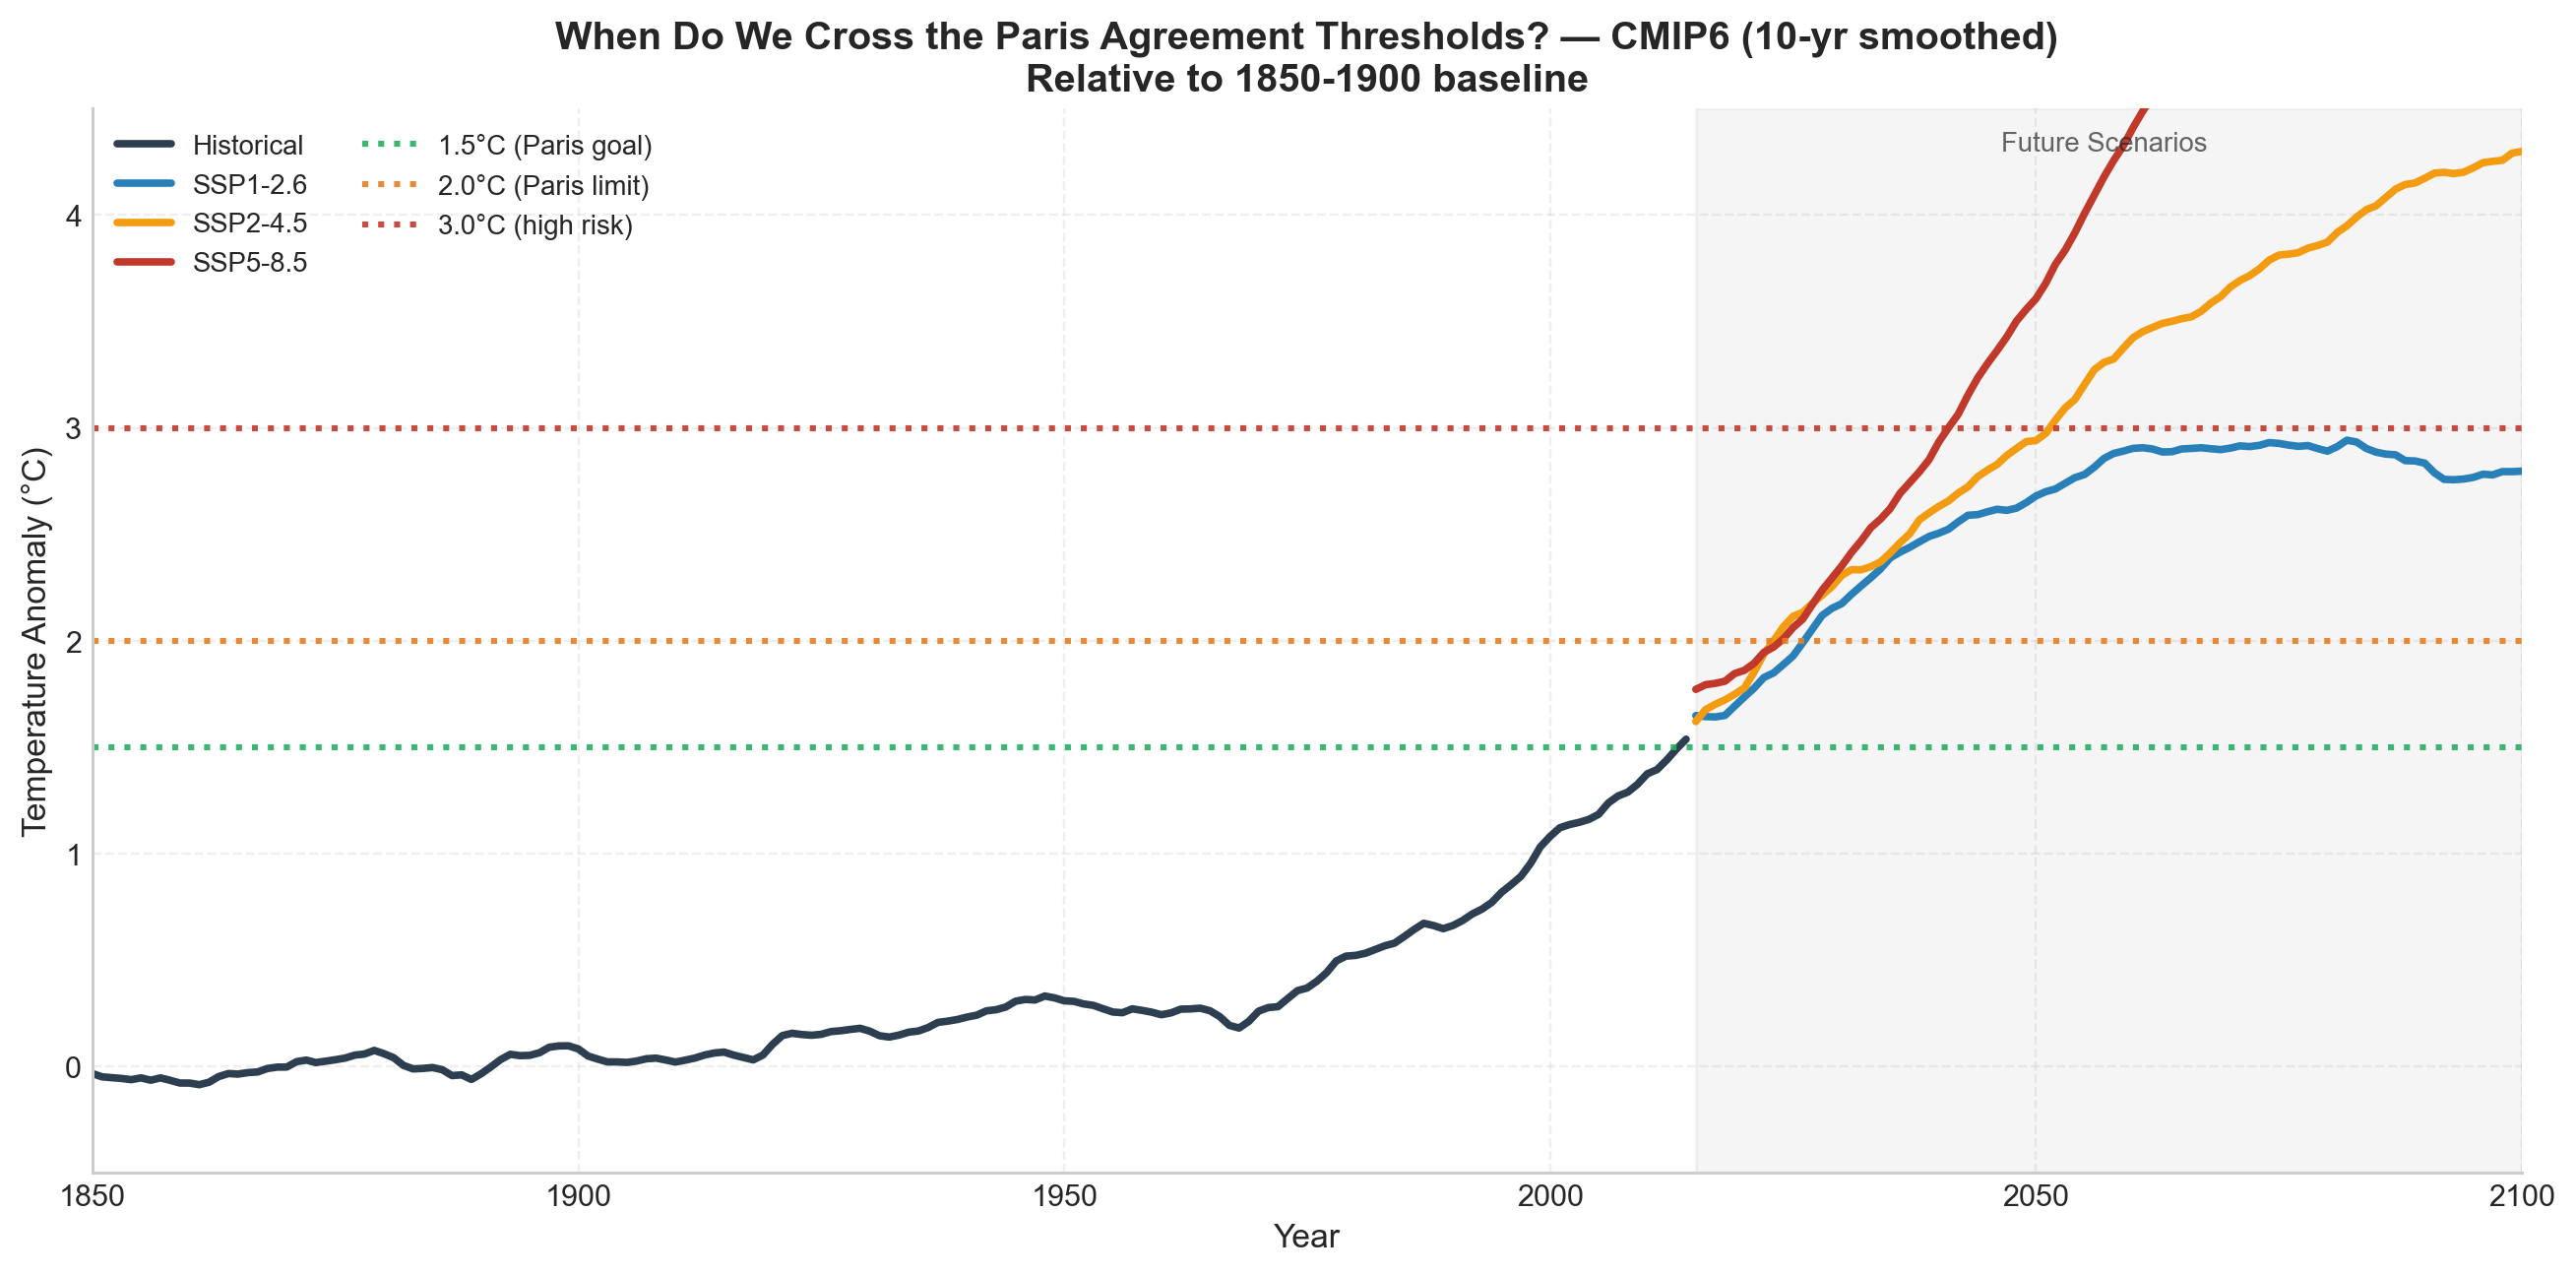

In [18]:
# Reuse already-loaded temperature data
try:
    gm_hist, gm_ssp126, gm_ssp245, gm_ssp
except NameError:
    print('Temperature data not loaded; skipping threshold crossing plot.')
else:
    baseline = float(gm_hist.sel(time=slice('1850', '1900')).mean())
    
    # Compute anomalies and apply 10-year smoothing
    def smooth_series(da, baseline, window=10):
        anom = (da.values - baseline)
        years = np.array([int(str(t)[:4]) for t in da.time.values])
        smooth = pd.Series(anom).rolling(window=window, center=True, min_periods=1).mean().values
        return years, smooth
    
    y_h, a_h = smooth_series(gm_hist, baseline)
    y_126, a_126 = smooth_series(gm_ssp126, baseline)
    y_245, a_245 = smooth_series(gm_ssp245, baseline)
    y_585, a_585 = smooth_series(gm_ssp, baseline)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(y_h, a_h, color='#2c3e50', lw=2.5, label='Historical')
    ax.plot(y_126, a_126, color='#2980b9', lw=2.5, label='SSP1-2.6')
    ax.plot(y_245, a_245, color='#f39c12', lw=2.5, label='SSP2-4.5')
    ax.plot(y_585, a_585, color='#c0392b', lw=2.5, label='SSP5-8.5')
    
    # Add threshold lines with labels
    ax.axhline(1.5, color='#27ae60', linestyle=':', lw=2, alpha=0.9, label='1.5°C (Paris goal)')
    ax.axhline(2.0, color='#e67e22', linestyle=':', lw=2, alpha=0.9, label='2.0°C (Paris limit)')
    ax.axhline(3.0, color='#c0392b', linestyle=':', lw=2, alpha=0.9, label='3.0°C (high risk)')
    
    # Add vertical shading for future
    ax.axvspan(2015, 2100, alpha=0.08, color='gray')
    ax.text(2057, 4.3, 'Future Scenarios', fontsize=9, ha='center', alpha=0.7)
    
    ax.set_xlim(1850, 2100)
    ax.set_ylim(-0.5, 4.5)
    ax.set_title('When Do We Cross the Paris Agreement Thresholds? — CMIP6 (10-yr smoothed)\n'
                 'Relative to 1850-1900 baseline', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=11)
    ax.legend(ncol=2, fontsize=9, loc='upper left')
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

["---", "### Bonus Plot 2 \u2014 Projected Regional Temperature Change by Scenario", "", "**What the plot shows:**", "Side-by-side maps comparing temperature change at the end of the 21st century (2071\u20132100) versus the pre-industrial baseline (1850\u20131900) for two contrasting emissions pathways: SSP2-4.5 (left, moderate emissions with modest mitigation) and SSP5-8.5 (right, high emissions with minimal climate action). Color intensity represents warming magnitude.", "", "**How to read warming by region (y-axis: latitude):**", "- **Color scale interpretation**: Darker red = greater warming; light/blue = less warming", "- **Horizontal gradient (latitude bands)**:", "  - **Polar regions (top/bottom, 60\u201390\u00b0)**: Show darkest reds \u2192 **polar amplification** (Arctic warming 2\u20134\u00d7 faster than tropics)", "  - **Mid-latitudes (30\u201360\u00b0)**: Moderate warming (orange/red)", "  - **Tropics (near equator)**: Least warming but still significant (yellow/light orange)", "- **SSP2-4.5 scale** (0\u20134\u00b0C max) shows warming capped by mitigation", "- **SSP5-8.5 scale** (0\u20138\u00b0C max) shows extreme Arctic warming \u2192 demonstrates why emissions choices matter", "", "**Why this regional pattern matters for climate change:**", "Polar amplification happens because melting ice reflects less sunlight, sea ice loss exposes dark ocean, and atmospheric moisture feedback strengthens warming. This regional difference is critical: Arctic warming drives jet stream destabilization (wild weather in mid-latitudes), permafrost collapse (releases ancient carbon), and sea-level rise (Greenland/Antarctic ice sheet collapse). Tropical regions, while warming less absolutely, already live near heat stress limits, so even +1.5\u00b0C there threatens agricultural productivity.", "", "**Real-world negative impacts of uneven warming:**", "- **Arctic regions (fastest warming)**: ", "  - Indigenous communities lose food security (declining seal, whale, fish populations)",", "  - Infrastructure built on permafrost collapses (roads, buildings crack)",", "  - Methane release accelerates warming in runaway feedback loop", "- **Mid-latitudes (e.g., North America, Europe)**:", "  - Jet stream becomes \u2018stuck,\u2019 trapping heat waves and cold snaps",", "  - Agriculture shifts poleward (soil in new regions often poor quality)",", "  - Seasonal patterns flip (spring arrives earlier, disrupts pollinator-plant synchrony)", "- **Tropics (steepest decline in human habitability)**:", "  - Wet-bulb temperatures exceed human survival thresholds",", "  - Monsoon patterns destabilize, triggering crop failures",", "  - Disease vectors (dengue, malaria mosquitoes) expand northward and upward in elevation", "", "**What the warming values (color scale) mean:**", "The color bars show temperature change in \u00b0C. For example, a +5\u00b0C change at 75\u00b0N Arctic means summer surface air there will be 5\u00b0C warmer than 1850\u20131900. This doesn't mean \u2018it will be 5\u00b0C warm\u2019 (it will still be cold), but the **rate of change** is what ecosystems and societies struggle to adapt to. A +5\u00b0C shift in 50 years is a pace rarely seen in the geological record outside of catastrophic events."]

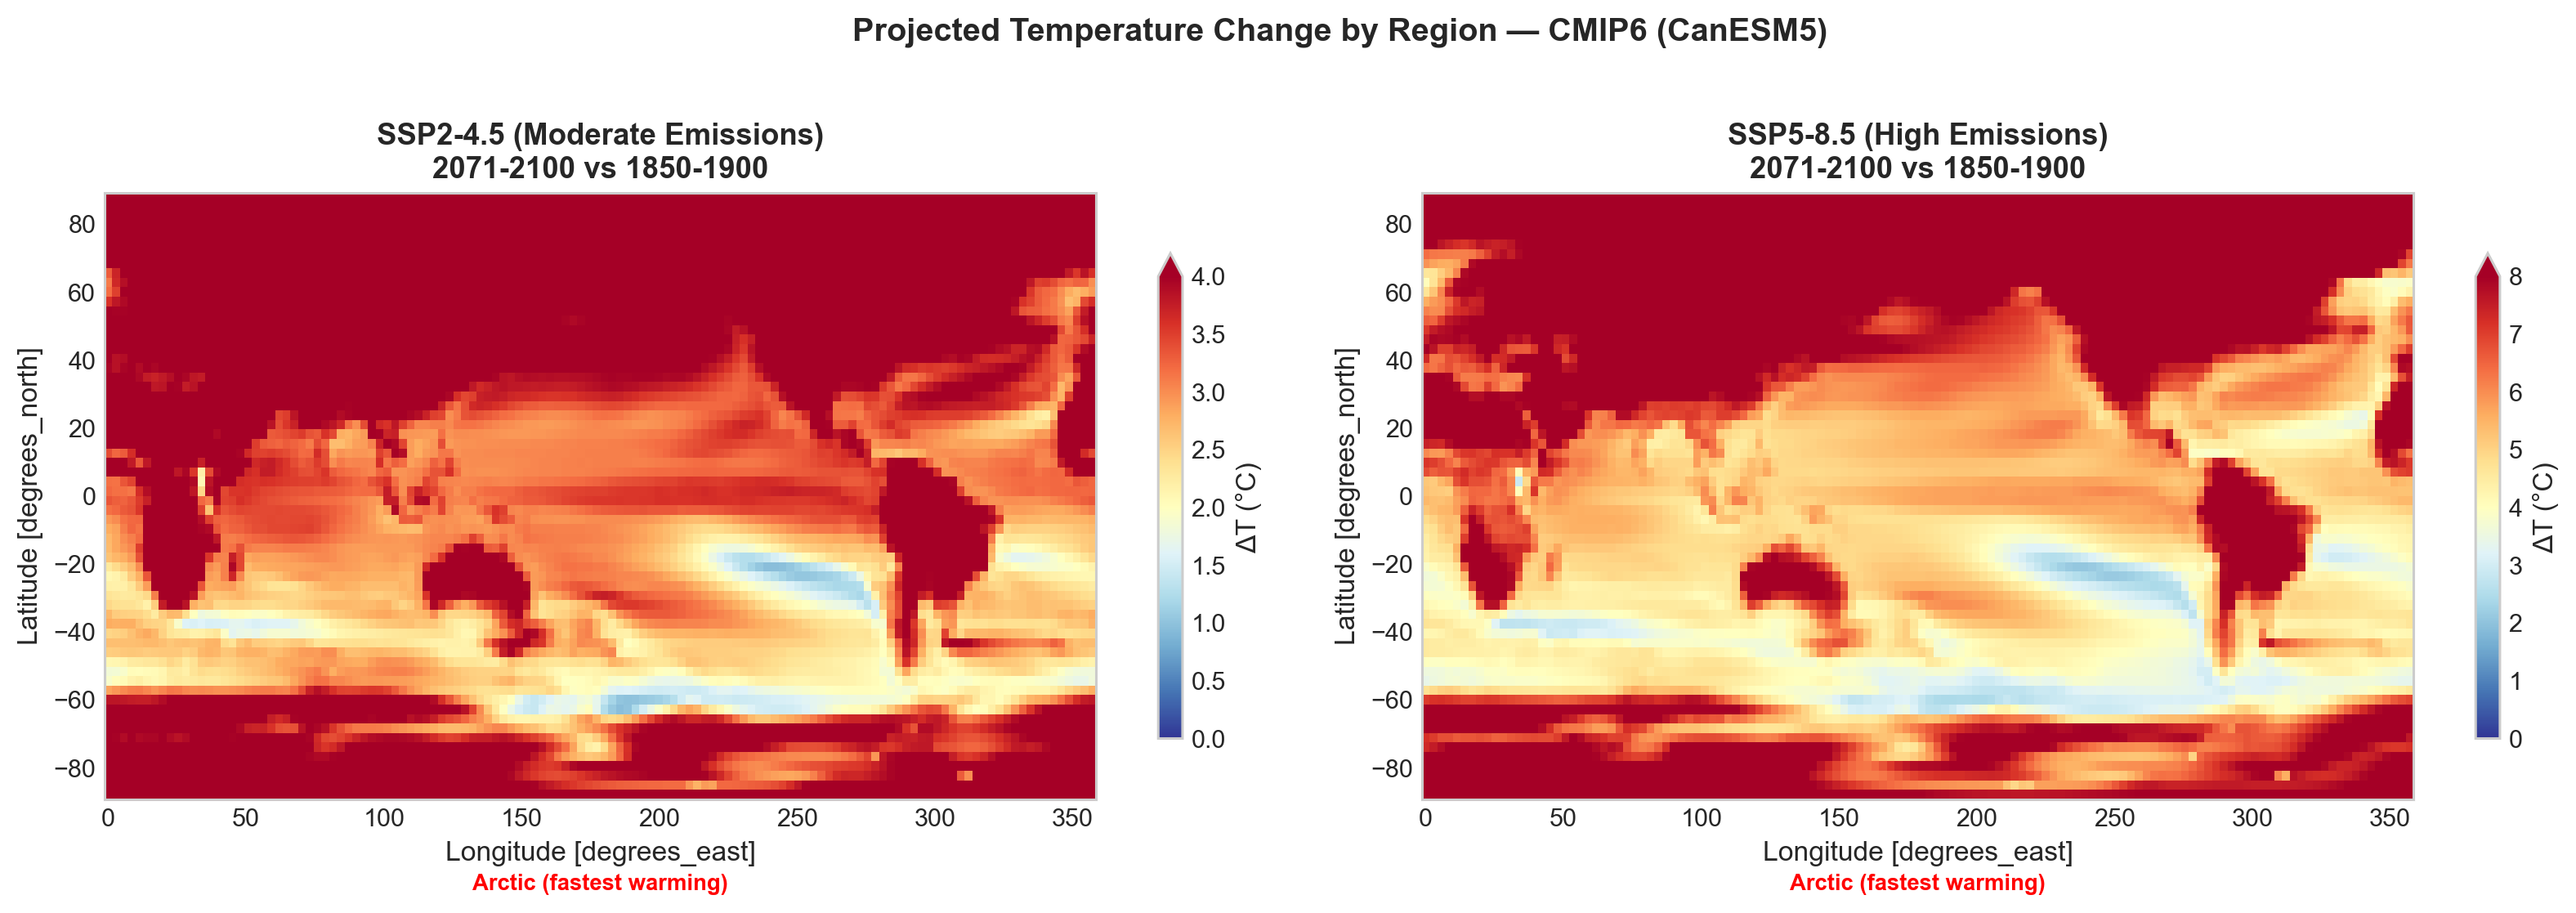

In [19]:
# Load or reuse SSP datasets
try:
    ds_ssp245
except NameError:
    ds_ssp245 = open_cmip6('tas', 'ssp245')
try:
    ds_ssp, ds_hist
except NameError:
    ds_ssp = open_cmip6('tas', 'ssp585')
    ds_hist = open_cmip6('tas', 'historical')

# Compute regional warming maps: 2071-2100 vs 1850-1900
baseline_map = ds_hist['tas'].sel(time=slice('1850', '1900')).mean('time') - 273.15
future_245 = ds_ssp245['tas'].sel(time=slice('2071', '2100')).mean('time') - 273.15
future_585 = ds_ssp['tas'].sel(time=slice('2071', '2100')).mean('time') - 273.15

warming_245 = future_245 - baseline_map
warming_585 = future_585 - baseline_map

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

warming_245.plot(ax=ax1, cmap='RdYlBu_r', vmin=0, vmax=4,
                 cbar_kwargs={'label': 'ΔT (°C)', 'shrink': 0.8})
ax1.set_title('SSP2-4.5 (Moderate Emissions)\n2071-2100 vs 1850-1900', fontsize=12, fontweight='bold')
ax1.text(0.5, -0.15, 'Arctic (fastest warming)', ha='center', fontsize=9, transform=ax1.transAxes, color='red', fontweight='bold')

warming_585.plot(ax=ax2, cmap='RdYlBu_r', vmin=0, vmax=8,
                 cbar_kwargs={'label': 'ΔT (°C)', 'shrink': 0.8})
ax2.set_title('SSP5-8.5 (High Emissions)\n2071-2100 vs 1850-1900', fontsize=12, fontweight='bold')
ax2.text(0.5, -0.15, 'Arctic (fastest warming)', ha='center', fontsize=9, transform=ax2.transAxes, color='red', fontweight='bold')

plt.suptitle('Projected Temperature Change by Region — CMIP6 (CanESM5)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### Bonus Plot 3 — Seasonal Warming Amplification by Region

**What the plot shows:**
Three panels display monthly temperature profiles for three latitude bands under two scenarios: historical baseline (dark navy line) versus SSP5-8.5 year 2100 (red line). The shaded region between them shows the magnitude of projected warming each month. Arctic (left), Tropics (middle), and Mid-latitudes (right) each display distinct seasonal signatures.

**How to read seasonal differences (x-axis: months, y-axis: temperature):**
- **Arctic panel (left)**:
  - Historical temperatures range from −20°C (winter) to +5°C (summer) → extreme seasonal swings
  - By 2100 (red), winter warms to ~+2°C and summer to ~+18°C → **+25°C peak warming in winter**
  - Arctic amplification is strongest in winter (ice-albedo feedback peaks)
- **Tropics panel (middle)**:
  - Historical range narrow: ~24–26°C (stable year-round) → tropical regions have minimal seasonal variation
  - By 2100 (red), stays ~33–35°C → **+9.7°C increase, but remains consistently hot**
  - The plateau is **dangerous**: organisms evolved for stable conditions now face year-round heat stress
- **Mid-latitudes panel (right)**:
  - Historical range: ~0°C (winter) to ~18°C (summer) → moderate seasonality
  - By 2100 (red): ~12°C (winter) to ~32°C (summer) → **+14°C peak warming in summer**
  - Summer becomes dangerously hot; winter loses cold-dependent ecosystem processes (dormancy, snow cover)

**Why seasonal patterns matter for climate change:**
Organisms have evolved rhythms tied to daylight and temperature cues: plants bud when soil warms, animals migrate based on photo-period + temperature, insects time reproduction to host-plant peak. Warming changes these cues asynchronously—springs arrive earlier, insects emerge before plants are ready (**phenological mismatch**). Arctic winter amplification destabilizes the polar vortex, pushing cold air southward in sudden winter storms; tropical year-round heat stress causes coral bleaching and heat-related mortality. Mid-latitude summer extremes drive crop failures and heat-wave deaths.

**Real-world negative impacts of seasonal disruption:**
- **Arctic**: Earlier spring sea-ice melt strands polar bears on shore; permafrost thaw destabilizes infrastructure; winter rain-on-snow events freeze forage, starving caribou and musk oxen.
- **Tropics**: Coral reefs bleach when temperatures exceed thermal tolerance (~27°C), losing symbiotic algae and ecosystem function; human wet-bulb heat stress (when sweat can't evaporate due to humidity) becomes lethal.
- **Mid-latitudes**: Late spring frosts kill early-budding fruit crops; mismatched insect-pollinator phenology reduces crop yields; prolonged summer heat triggers simultaneous wildfires across regions normally separated by climate barriers.

**What seasonal peaks (y-axis values) mean:**
The temperature values are **absolute temperature in °C**, not anomalies. In the Arctic, the historical June mean is ~+5°C while the historical January mean is ~−20°C. The +25°C warming shown as peak winter increase means January 2100 will average ~+2 to +5°C instead of ~−20°C—an unprecedented departure from the Arctic's normal winter state. This degree of seasonal shift is why Arctic ecosystems face collapse: species cannot migrate further north (it's the pole) and cannot physiologically tolerate the new conditions fast enough.

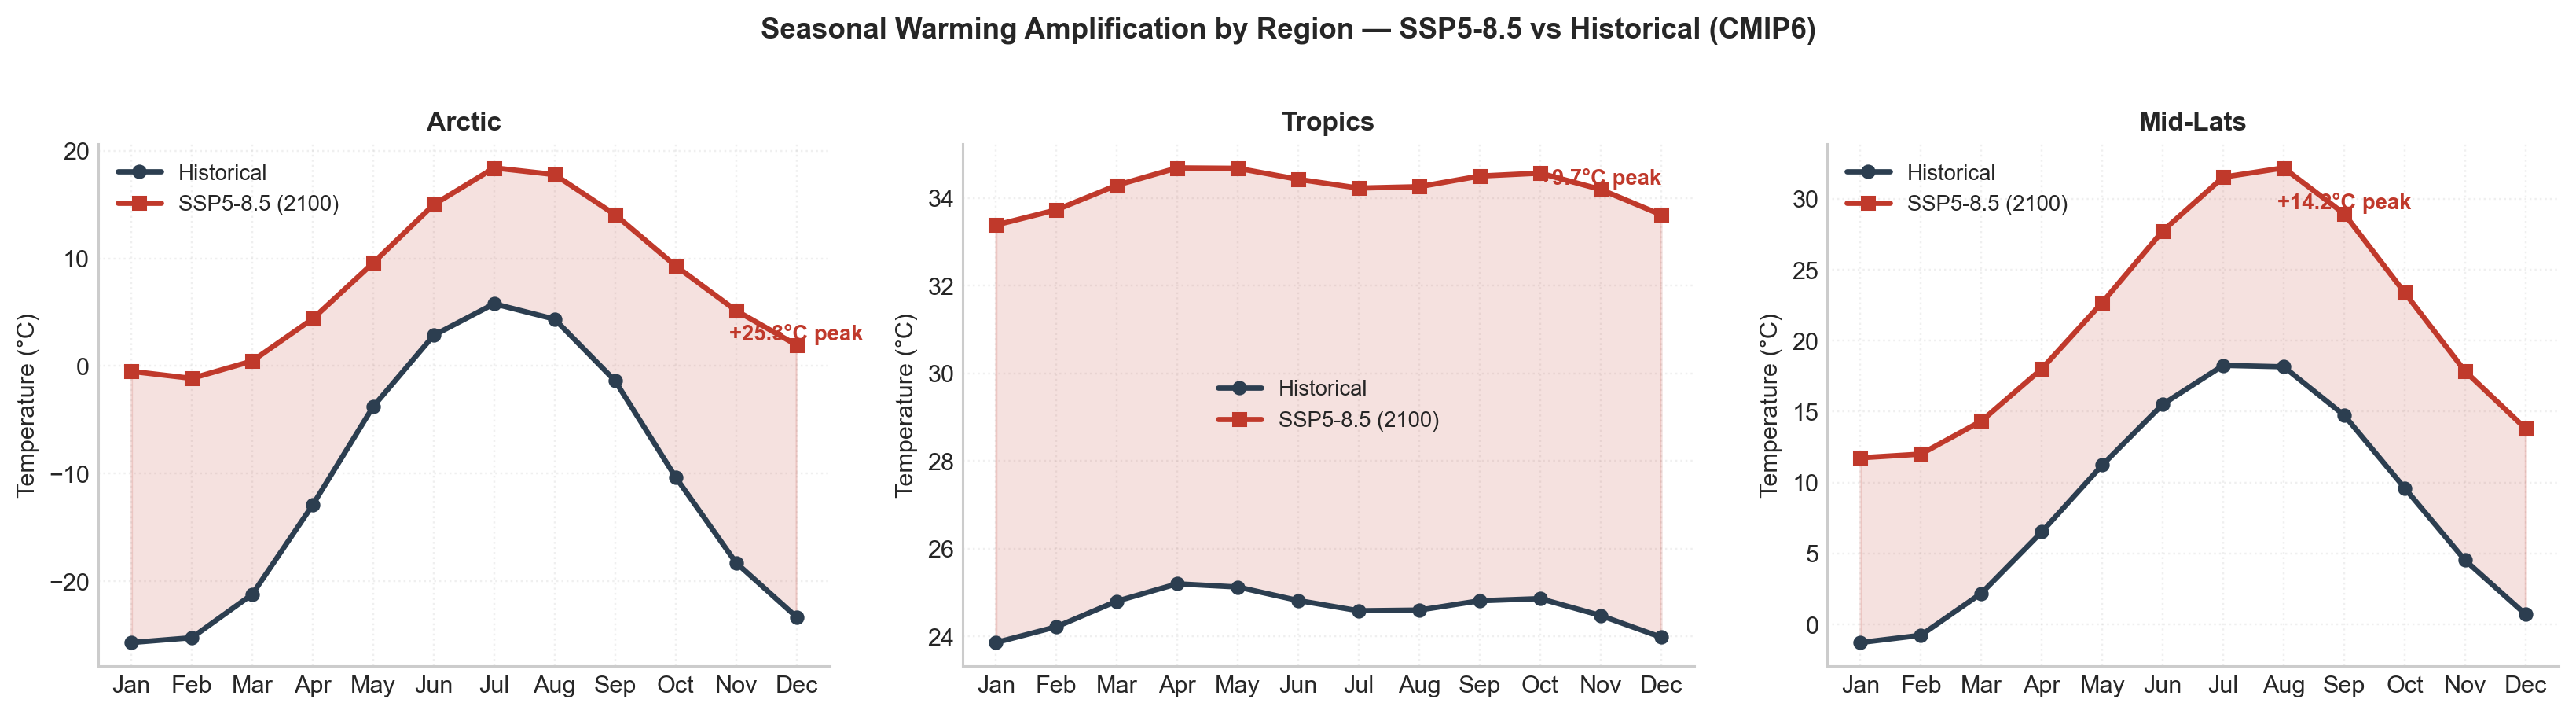

In [20]:
# Define latitude bands
def get_regional_monthly_temp(ds_hist, ds_ssp, region_name, lat_min, lat_max):
    lat_name = next((c for c in ds_hist['tas'].coords if 'lat' in c.lower()), None)
    if lat_name is None:
        raise ValueError(f'Could not find latitude coordinate for {region_name}.')
    
    # Select region and compute monthly mean for each year
    tas_hist = ds_hist['tas'].sel({lat_name: slice(lat_min, lat_max)}) - 273.15
    tas_ssp = ds_ssp['tas'].sel({lat_name: slice(lat_min, lat_max)}) - 273.15
    
    # Area-weighted mean over region
    weights = np.cos(np.deg2rad(ds_hist[lat_name].sel({lat_name: slice(lat_min, lat_max)})))
    weights.name = 'weights'
    
    # Group by month and compute climatology
    monthly_hist = []
    monthly_ssp = []
    
    for month in range(1, 13):
        h_sel = tas_hist.isel(time=(ds_hist.time.dt.month == month).values).weighted(weights).mean(['lat', 'lon'])
        s_sel = tas_ssp.isel(time=(ds_ssp.time.dt.month == month).values).weighted(weights).mean(['lat', 'lon'])
        monthly_hist.append(float(h_sel.mean()))
        monthly_ssp.append(float(s_sel.mean()))
    
    return region_name, np.array(monthly_hist), np.array(monthly_ssp)

# Compute for three regions
try:
    ds_hist, ds_ssp
except NameError:
    ds_hist = open_cmip6('tas', 'historical')
    ds_ssp = open_cmip6('tas', 'ssp585')

arctic_name, arctic_hist, arctic_ssp = get_regional_monthly_temp(ds_hist, ds_ssp, 'Arctic', 60, 90)
tropics_name, tropics_hist, tropics_ssp = get_regional_monthly_temp(ds_hist, ds_ssp, 'Tropics', -30, 30)
midlat_name, midlat_hist, midlat_ssp = get_regional_monthly_temp(ds_hist, ds_ssp, 'Mid-Lats', 30, 60)

months = np.arange(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
regions = [
    (arctic_name, arctic_hist, arctic_ssp, axes[0]),
    (tropics_name, tropics_hist, tropics_ssp, axes[1]),
    (midlat_name, midlat_hist, midlat_ssp, axes[2]),
]

for region_name, hist, ssp, ax in regions:
    warming = ssp - hist
    peak_warming = np.max(warming)
    peak_month = np.argmax(warming) + 1
    
    ax.plot(months, hist, 'o-', color='#2c3e50', lw=2.2, markersize=5, label='Historical')
    ax.plot(months, ssp, 's-', color='#c0392b', lw=2.2, markersize=5, label='SSP5-8.5 (2100)')
    ax.fill_between(months, hist, ssp, alpha=0.15, color='#c0392b')
    
    ax.set_xticks(months)
    ax.set_xticklabels(month_names)
    ax.set_title(f'{region_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Temperature (°C)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle=':')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Annotate peak warming
    ax.text(peak_month, ssp[peak_month-1], f'+{peak_warming:.1f}°C peak', 
            fontsize=9, ha='center', va='bottom', color='#c0392b', fontweight='bold')

fig.suptitle('Seasonal Warming Amplification by Region — SSP5-8.5 vs Historical (CMIP6)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

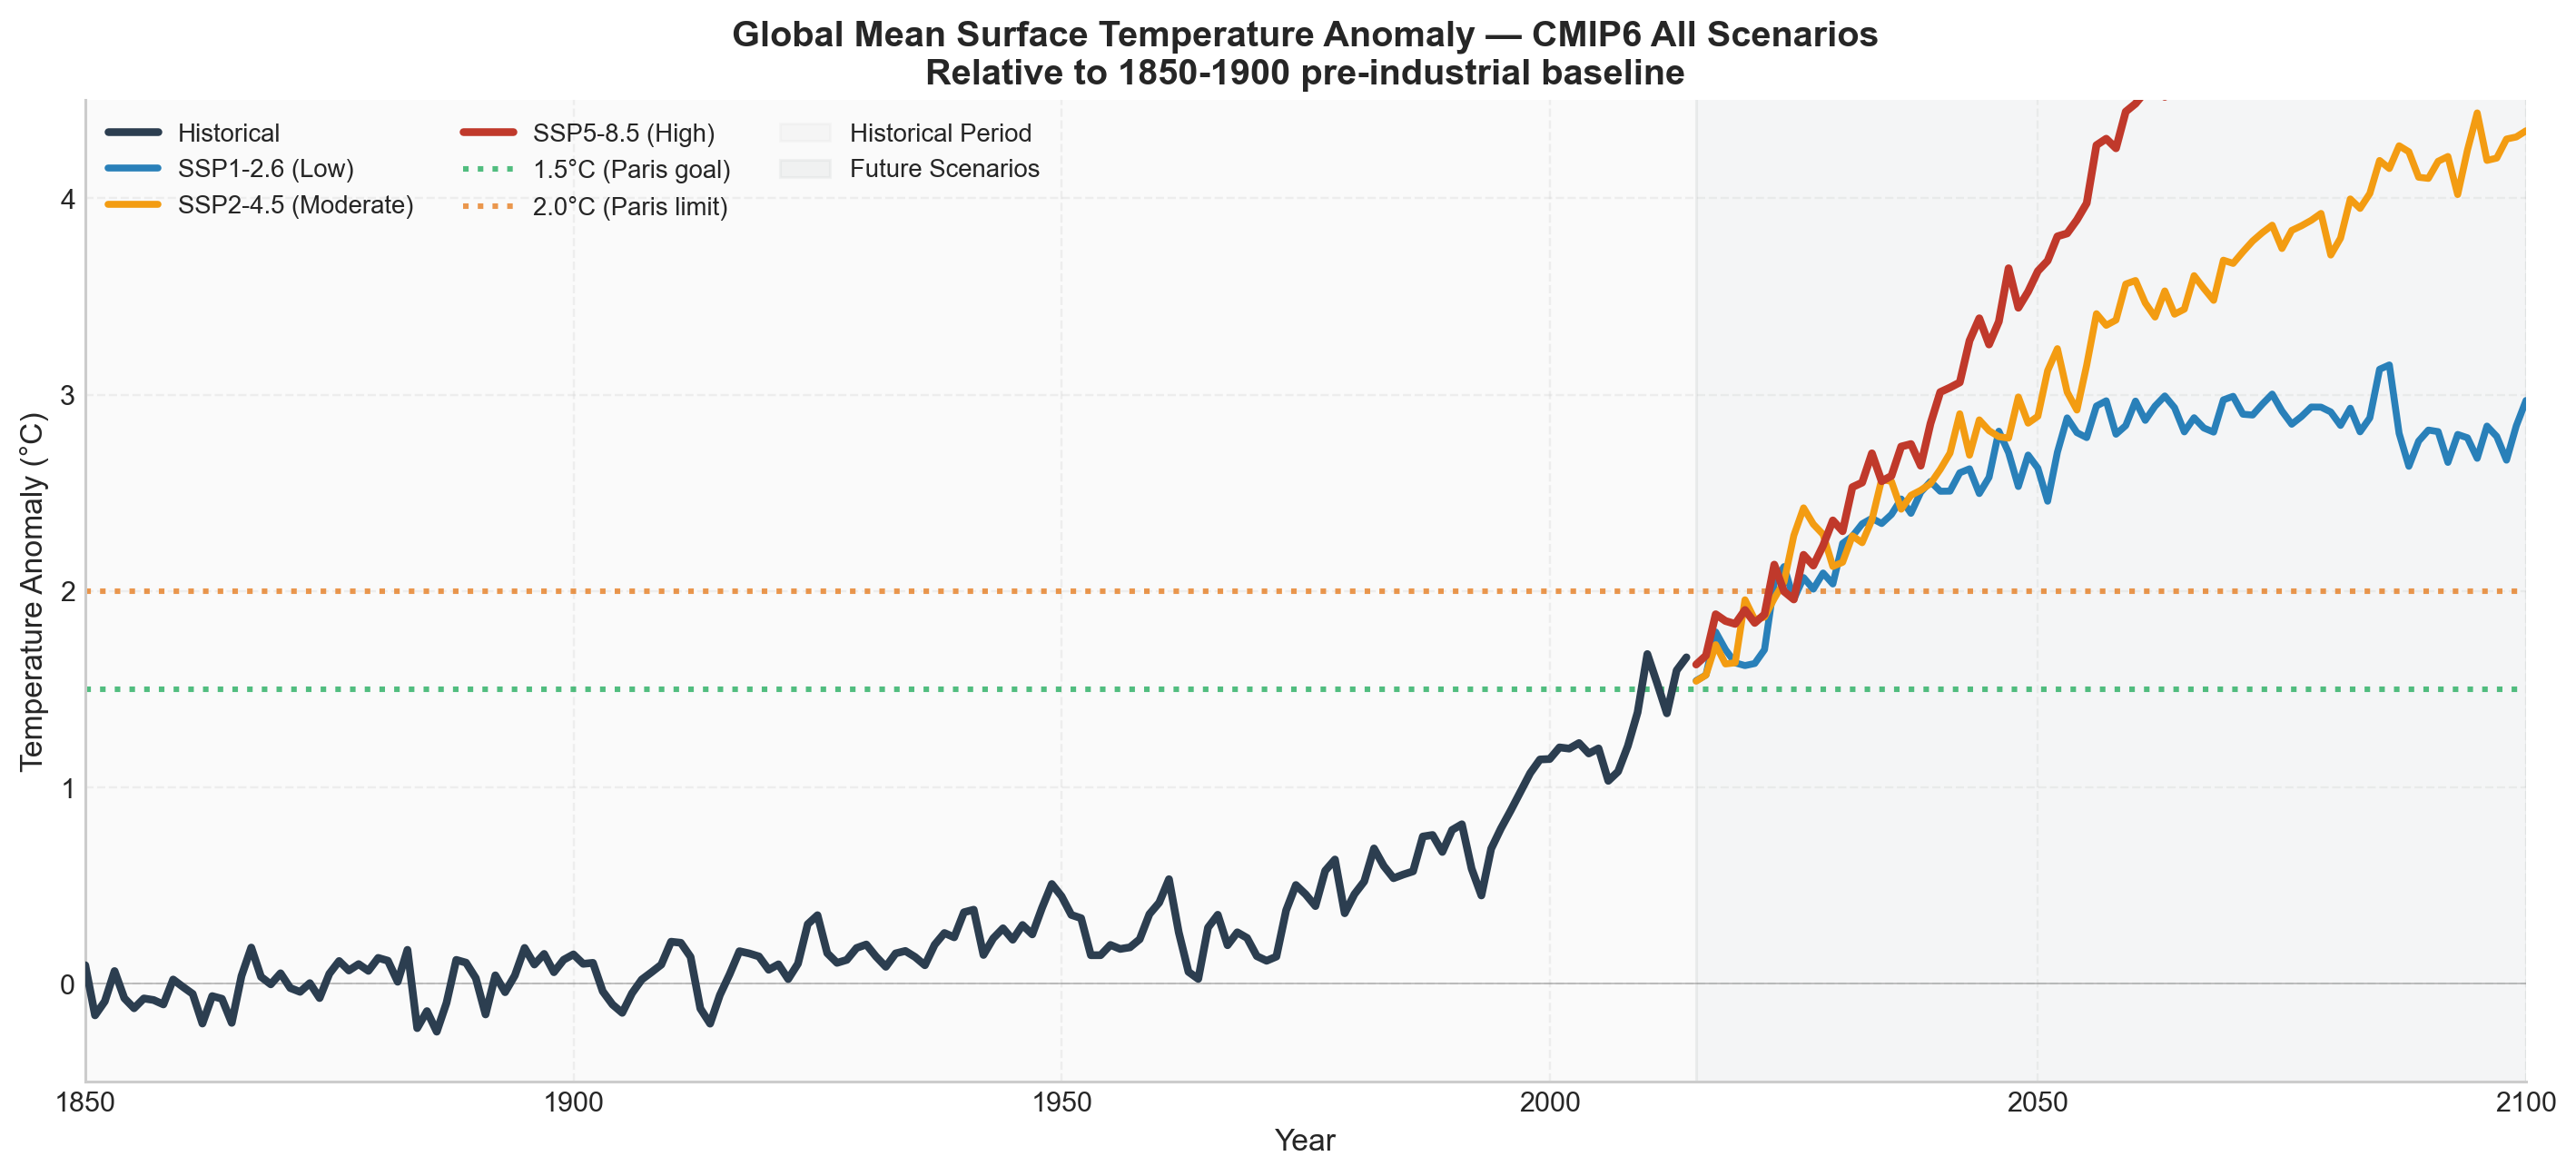

In [21]:
# Comprehensive SSP comparison with all pathways
try:
    gm_hist, gm_ssp, gm_ssp126, gm_ssp245
except NameError:
    print('Loading temperature data for comprehensive SSP plot...')
    ds_hist = open_cmip6('tas', 'historical')
    ds_ssp = open_cmip6('tas', 'ssp585')
    ds_ssp126 = open_cmip6('tas', 'ssp126')
    ds_ssp245 = open_cmip6('tas', 'ssp245')
    
    def global_mean_C(ds, var='tas'):
        w = np.cos(np.deg2rad(ds.lat))
        w.name = 'weights'
        return (ds[var].weighted(w).mean(('lat', 'lon')) - 273.15).resample(time='YE').mean()
    
    gm_hist = global_mean_C(ds_hist)
    gm_ssp = global_mean_C(ds_ssp)
    gm_ssp126 = global_mean_C(ds_ssp126)
    gm_ssp245 = global_mean_C(ds_ssp245)

baseline = float(gm_hist.sel(time=slice('1850', '1900')).mean())

def to_years(da):
    return np.array([int(str(t)[:4]) for t in da.time.values])

fig, ax = plt.subplots(figsize=(13, 6))

# Plot all SSP pathways
ax.plot(to_years(gm_hist), gm_hist.values - baseline, color='#2c3e50', lw=2.8, label='Historical', zorder=4)
ax.plot(to_years(gm_ssp126), (gm_ssp126.values - baseline)[:len(to_years(gm_ssp126))], 
        color='#2980b9', lw=2.5, label='SSP1-2.6 (Low)', linestyle='-', zorder=3)
ax.plot(to_years(gm_ssp245), (gm_ssp245.values - baseline)[:len(to_years(gm_ssp245))], 
        color='#f39c12', lw=2.5, label='SSP2-4.5 (Moderate)', linestyle='-', zorder=3)
ax.plot(to_years(gm_ssp), (gm_ssp.values - baseline)[:len(to_years(gm_ssp))], 
        color='#c0392b', lw=2.8, label='SSP5-8.5 (High)', linestyle='-', zorder=3)

# Add Paris Agreement thresholds
ax.axhline(1.5, color='#27ae60', linestyle=':', lw=2, alpha=0.8, label='1.5°C (Paris goal)')
ax.axhline(2.0, color='#e67e22', linestyle=':', lw=2, alpha=0.8, label='2.0°C (Paris limit)')
ax.axhline(0, color='gray', lw=0.6, alpha=0.5)

# Shading
ax.fill_between([1850, 2015], -1, 5, alpha=0.04, color='gray', label='Historical Period')
ax.fill_between([2015, 2100], -1, 5, alpha=0.08, color='#7f8c8d', label='Future Scenarios')

ax.set_xlim(1850, 2100)
ax.set_ylim(-0.5, 4.5)
ax.set_title('Global Mean Surface Temperature Anomaly — CMIP6 All Scenarios\n'
             'Relative to 1850-1900 pre-industrial baseline', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=11)
ax.legend(ncol=3, fontsize=9, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.25, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()